### Muhammad Salahuddin
### Student ID: 20244747

# Big Data and Data Mining

## Importing my libraries

In [3]:
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import statistics
import datetime
import matplotlib.pyplot as plt
import folium

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.neighbors import KernelDensity
from mpl_toolkits.mplot3d import Axes3D
from datetime import time
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from folium.plugins import MarkerCluster
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer



%matplotlib inline

#Suppress warnings
import warnings
warnings.filterwarnings('ignore')


## Connecting to the database

In [4]:
con = sqlite3.connect("accident_data_v1.0.0_2023.db")
cur = con.cursor()

## Table Headers

In [5]:
table_headers = cur.execute(f"SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").fetchall()
print("Table List in dataset")
for table in table_headers:
    print(table[0])

Table List in dataset
accident
casualty
lsoa
vehicle


In [6]:
def dataframe_generator(y, accident_year=False):
    
# Creating an empty list
    y_ = []
    
# Getting the column names
    col_info = cur.execute(f"PRAGMA table_info('{y}')")
    y_col = col_info.fetchall()
    
# Iterating through the columns
    for i in y_col:
        y_.append(i[1])
    
# Executing the cursor
    if accident_year == True:
        res = cur.execute(f"SELECT * FROM '{y}' WHERE accident_year = 2019")
        new = res.fetchall()
    else:
        res = cur.execute(f"SELECT * FROM '{y}'")
        new = res.fetchall()
    
# Creating a dataframe for the table
    y_df = pd.DataFrame(new, columns=y_)
    y_df
    

    return y_df

In [7]:
accident_2019 = dataframe_generator('accident', accident_year=True)
casualty_2019 = dataframe_generator('casualty', accident_year=True)
vehicle_2019 = dataframe_generator('vehicle', accident_year=True)
lsoa_2019 = dataframe_generator('lsoa')

In [8]:
con.close()

In [9]:
# Creating a copy of the data

accident_df = accident_2019.copy()
vehicle_df = vehicle_2019.copy()
casualty_df = casualty_2019.copy()

## Inspecting the data

In [10]:
accident_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117536 entries, 0 to 117535
Data columns (total 36 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   accident_index                               117536 non-null  object 
 1   accident_year                                117536 non-null  int64  
 2   accident_reference                           117536 non-null  object 
 3   location_easting_osgr                        117508 non-null  float64
 4   location_northing_osgr                       117508 non-null  float64
 5   longitude                                    117508 non-null  float64
 6   latitude                                     117508 non-null  float64
 7   police_force                                 117536 non-null  int64  
 8   accident_severity                            117536 non-null  int64  
 9   number_of_vehicles                           117536 non-nul

In [11]:
vehicle_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216381 entries, 0 to 216380
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype 
---  ------                            --------------   ----- 
 0   vehicle_index                     216381 non-null  int64 
 1   accident_index                    216381 non-null  object
 2   accident_year                     216381 non-null  int64 
 3   accident_reference                216381 non-null  object
 4   vehicle_reference                 216381 non-null  int64 
 5   vehicle_type                      216381 non-null  int64 
 6   towing_and_articulation           216381 non-null  int64 
 7   vehicle_manoeuvre                 216381 non-null  int64 
 8   vehicle_direction_from            216381 non-null  int64 
 9   vehicle_direction_to              216381 non-null  int64 
 10  vehicle_location_restricted_lane  216381 non-null  int64 
 11  junction_location                 216381 non-null  int64 
 12  sk

In [12]:
casualty_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153158 entries, 0 to 153157
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   casualty_index                      153158 non-null  int64 
 1   accident_index                      153158 non-null  object
 2   accident_year                       153158 non-null  int64 
 3   accident_reference                  153158 non-null  object
 4   vehicle_reference                   153158 non-null  int64 
 5   casualty_reference                  153158 non-null  int64 
 6   casualty_class                      153158 non-null  int64 
 7   sex_of_casualty                     153158 non-null  int64 
 8   age_of_casualty                     153158 non-null  int64 
 9   age_band_of_casualty                153158 non-null  int64 
 10  casualty_severity                   153158 non-null  int64 
 11  pedestrian_location                 153

In [13]:
lsoa_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34378 entries, 0 to 34377
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objectid       34378 non-null  int64  
 1   lsoa01cd       34378 non-null  object 
 2   lsoa01nm       34378 non-null  object 
 3   lsoa01nmw      34378 non-null  object 
 4   shape__area    34378 non-null  float64
 5   shape__length  34378 non-null  float64
 6   globalid       34378 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.8+ MB


### Inspecting the Accident table 

In [14]:
accident_2019.isnull().sum().sort_values(ascending = False)

location_easting_osgr                          28
location_northing_osgr                         28
longitude                                      28
latitude                                       28
accident_index                                  0
weather_conditions                              0
junction_control                                0
second_road_class                               0
second_road_number                              0
pedestrian_crossing_human_control               0
pedestrian_crossing_physical_facilities         0
light_conditions                                0
special_conditions_at_site                      0
road_surface_conditions                         0
speed_limit                                     0
carriageway_hazards                             0
urban_or_rural_area                             0
did_police_officer_attend_scene_of_accident     0
trunk_road_flag                                 0
junction_detail                                 0


In [15]:
# Checking for columns with negative values

def negative_columns(table):
    list_of_negatives = []
    values = [-1, '-1']
    for p in table.columns:
        if table[p].isin(values).any():
            list_of_negatives.append(p)
    return list_of_negatives

# Returning function
negative_columns(accident_2019)

['local_authority_highway',
 'speed_limit',
 'junction_detail',
 'junction_control',
 'second_road_class',
 'second_road_number',
 'pedestrian_crossing_human_control',
 'pedestrian_crossing_physical_facilities',
 'light_conditions',
 'road_surface_conditions',
 'special_conditions_at_site',
 'carriageway_hazards',
 'trunk_road_flag',
 'lsoa_of_accident_location']

In [16]:
# Checking each negative column individually

print (f"Negative values in local anthority highway column: {(len(accident_2019[accident_2019.local_authority_highway == -1]))}")

print (f"Negative values in speed limit column: {(len(accident_2019[accident_2019.speed_limit == -1]))}")

print (f"Negative values in junction detail column: {(len(accident_2019[accident_2019.junction_detail == -1]))}")

print (f"Negative values in junction control column: {(len(accident_2019[accident_2019.junction_control == -1]))}") 

print (f"Negative values in second road class column: {(len(accident_2019[accident_2019.second_road_class == -1]))}") 

print (f"Negative values in second road number column: {(len(accident_2019[accident_2019.second_road_number == -1]))}") 

print (f"Negative values in pedestrian crossing human control column: {(len(accident_2019[accident_2019.pedestrian_crossing_human_control == -1]))}") 

print (f"Negative values in pedestrian crossing physical facilities column: {(len(accident_2019[accident_2019.pedestrian_crossing_physical_facilities == -1]))}") 

print (f"Negative values in light conditions column: {(len(accident_2019[accident_2019.light_conditions == -1]))}") 

#print (f"Negative values in weather conditions column: {(len(accident_2019[accident_2019.weather_conditions == -1]))}")

print (f"Negative values in road surface conditions column: {(len(accident_2019[accident_2019.road_surface_conditions == -1]))}")

print (f"Negative values in special conditions at site column: {(len(accident_2019[accident_2019.special_conditions_at_site == -1]))}")

print (f"Negative values in carriageway hazards column: {(len(accident_2019[accident_2019.carriageway_hazards == -1]))}")

#print (f"Negative values in did police officer attend scene of accident column: {(len(accident_2019[accident_2019.did_police_officer_attend_scene_of_accident == -1]))}")

print (f"Negative values in trunk road flag column: {(len(accident_2019[accident_2019.trunk_road_flag == -1]))}")

print (f"Negative values in lsoa of accident location column: {(len(accident_2019[accident_2019.lsoa_of_accident_location == -1]))}")


Negative values in local anthority highway column: 0
Negative values in speed limit column: 80
Negative values in junction detail column: 1
Negative values in junction control column: 49366
Negative values in second road class column: 49106
Negative values in second road number column: 49106
Negative values in pedestrian crossing human control column: 161
Negative values in pedestrian crossing physical facilities column: 148
Negative values in light conditions column: 1
Negative values in road surface conditions column: 299
Negative values in special conditions at site column: 240
Negative values in carriageway hazards column: 230
Negative values in trunk road flag column: 10001
Negative values in lsoa of accident location column: 0


### Inspecting the Vehicle table

In [17]:
vehicle_2019.isnull().sum().sort_values(ascending = False)

vehicle_index                       0
accident_index                      0
driver_imd_decile                   0
generic_make_model                  0
age_of_vehicle                      0
propulsion_code                     0
engine_capacity_cc                  0
age_band_of_driver                  0
age_of_driver                       0
sex_of_driver                       0
journey_purpose_of_driver           0
vehicle_left_hand_drive             0
first_point_of_impact               0
hit_object_off_carriageway          0
vehicle_leaving_carriageway         0
hit_object_in_carriageway           0
skidding_and_overturning            0
junction_location                   0
vehicle_location_restricted_lane    0
vehicle_direction_to                0
vehicle_direction_from              0
vehicle_manoeuvre                   0
towing_and_articulation             0
vehicle_type                        0
vehicle_reference                   0
accident_reference                  0
accident_yea

In [18]:
# Calling the function for negative columns

negative_columns(vehicle_2019)

['vehicle_type',
 'towing_and_articulation',
 'vehicle_manoeuvre',
 'vehicle_direction_from',
 'vehicle_direction_to',
 'vehicle_location_restricted_lane',
 'junction_location',
 'skidding_and_overturning',
 'hit_object_in_carriageway',
 'vehicle_leaving_carriageway',
 'hit_object_off_carriageway',
 'first_point_of_impact',
 'vehicle_left_hand_drive',
 'journey_purpose_of_driver',
 'sex_of_driver',
 'age_of_driver',
 'age_band_of_driver',
 'engine_capacity_cc',
 'propulsion_code',
 'age_of_vehicle',
 'generic_make_model',
 'driver_imd_decile',
 'driver_home_area_type']

In [19]:
# Checking each negative column individually

print (f"Negative values in vehicle type column: {(len(vehicle_2019[vehicle_2019.vehicle_type == -1]))}")

print (f"Negative values in towing and articulation column: {(len(vehicle_2019[vehicle_2019.towing_and_articulation == -1]))}")

print (f"Negative values in vehicle_manoeuvre column: {(len(vehicle_2019[vehicle_2019.vehicle_manoeuvre == -1]))}")

print (f"Negative values in vehicle_direction_from column: {(len(vehicle_2019[vehicle_2019.vehicle_direction_from == -1]))}")

print (f"Negative values in vehicle_direction_to column: {(len(vehicle_2019[vehicle_2019.vehicle_direction_to == -1]))}")

print (f"Negative values in vehicle_location_restricted_lane column: {(len(vehicle_2019[vehicle_2019.vehicle_location_restricted_lane == -1]))}")

print (f"Negative values in junction_location column: {(len(vehicle_2019[vehicle_2019.junction_location == -1]))}")

print (f"Negative values in skidding_and_overturning column: {(len(vehicle_2019[vehicle_2019.skidding_and_overturning == -1]))}")

print (f"Negative values in hit_object_in_carriageway column: {(len(vehicle_2019[vehicle_2019.hit_object_in_carriageway == -1]))}")

print (f"Negative values in vehicle_leaving_carriageway column: {(len(vehicle_2019[vehicle_2019.vehicle_leaving_carriageway == -1]))}")

print (f"Negative values in hit_object_off_carriageway column: {(len(vehicle_2019[vehicle_2019.hit_object_off_carriageway == -1]))}")

print (f"Negative values in first_point_of_impact column: {(len(vehicle_2019[vehicle_2019.first_point_of_impact == -1]))}")

print (f"Negative values in vehicle_left_hand_drive column: {(len(vehicle_2019[vehicle_2019.vehicle_left_hand_drive == -1]))}")

print (f"Negative values in journey_purpose_of_driver column: {(len(vehicle_2019[vehicle_2019.journey_purpose_of_driver == -1]))}")

print (f"Negative values in sex_of_driver column: {(len(vehicle_2019[vehicle_2019.sex_of_driver == -1]))}")

print (f"Negative values in age_of_driver column: {(len(vehicle_2019[vehicle_2019.age_of_driver == -1]))}")

print (f"Negative values in age band of driver column: {(len(vehicle_2019[vehicle_2019.age_band_of_driver == -1]))}")

print (f"Negative values in engine capacity cc column: {(len(vehicle_2019[vehicle_2019.engine_capacity_cc == -1]))}")

print (f"Negative values in propulsion code column: {(len(vehicle_2019[vehicle_2019.propulsion_code == -1]))}")

print (f"Negative values in age of vehicle column: {(len(vehicle_2019[vehicle_2019.age_of_vehicle == -1]))}")

print (f"Negative values in generic make model column: {(len(vehicle_2019[vehicle_2019.generic_make_model == -1]))}")

print (f"Negative values in driver imd decile column: {(len(vehicle_2019[vehicle_2019.driver_imd_decile == -1]))}")

print (f"Negative values in driver home area type column: {(len(vehicle_2019[vehicle_2019.driver_home_area_type == -1]))}")



Negative values in vehicle type column: 259
Negative values in towing and articulation column: 803
Negative values in vehicle_manoeuvre column: 592
Negative values in vehicle_direction_from column: 1904
Negative values in vehicle_direction_to column: 2235
Negative values in vehicle_location_restricted_lane column: 597
Negative values in junction_location column: 268
Negative values in skidding_and_overturning column: 672
Negative values in hit_object_in_carriageway column: 588
Negative values in vehicle_leaving_carriageway column: 620
Negative values in hit_object_off_carriageway column: 12
Negative values in first_point_of_impact column: 781
Negative values in vehicle_left_hand_drive column: 214
Negative values in journey_purpose_of_driver column: 58
Negative values in sex_of_driver column: 1
Negative values in age_of_driver column: 29756
Negative values in age band of driver column: 29756
Negative values in engine capacity cc column: 54958
Negative values in propulsion code column: 5

### Inspecting the Casualty Table

In [20]:
casualty_2019.isnull().sum().sort_values(ascending = False)

casualty_index                        0
casualty_severity                     0
casualty_home_area_type               0
casualty_type                         0
pedestrian_road_maintenance_worker    0
bus_or_coach_passenger                0
car_passenger                         0
pedestrian_movement                   0
pedestrian_location                   0
age_band_of_casualty                  0
accident_index                        0
age_of_casualty                       0
sex_of_casualty                       0
casualty_class                        0
casualty_reference                    0
vehicle_reference                     0
accident_reference                    0
accident_year                         0
casualty_imd_decile                   0
dtype: int64

In [21]:
# Calling the function for negative columns

negative_columns(casualty_2019)

['sex_of_casualty',
 'age_of_casualty',
 'age_band_of_casualty',
 'pedestrian_location',
 'car_passenger',
 'bus_or_coach_passenger',
 'pedestrian_road_maintenance_worker',
 'casualty_type',
 'casualty_home_area_type',
 'casualty_imd_decile']

In [22]:
# Checking the negative columns individually

print (f"Negative values in sex_of_casualty column: {(len(casualty_2019[casualty_2019.sex_of_casualty == -1]))}")

print (f"Negative values in age_of_casualty column: {(len(casualty_2019[casualty_2019.age_of_casualty == -1]))}")

print (f"Negative values in age_band_of_casualty column: {(len(casualty_2019[casualty_2019.age_band_of_casualty == -1]))}")

print (f"Negative values in pedestrian_location column: {(len(casualty_2019[casualty_2019.pedestrian_location == -1]))}")

#print (f"Negative values in pedestrian_movement column: {(len(casualty_2019[casualty_2019.pedestrian_movement == -1]))}")

print (f"Negative values in car_passenger column: {(len(casualty_2019[casualty_2019.car_passenger == -1]))}")

print (f"Negative values in bus_or_coach_passenger column: {(len(casualty_2019[casualty_2019.bus_or_coach_passenger == -1]))}")

print (f"Negative values in pedestrian_road_maintenance_worker column: {(len(casualty_2019[casualty_2019.pedestrian_road_maintenance_worker == -1]))}")

print (f"Negative values in casualty type column: {(len(casualty_2019[casualty_2019.casualty_type == -1]))}")

print (f"Negative values in casualty_home_area_type column: {(len(casualty_2019[casualty_2019.casualty_home_area_type == -1]))}")

print (f"Negative values in casualty_imd_decile column: {(len(casualty_2019[casualty_2019.casualty_imd_decile == -1]))}")


Negative values in sex_of_casualty column: 724
Negative values in age_of_casualty column: 3255
Negative values in age_band_of_casualty column: 3255
Negative values in pedestrian_location column: 1
Negative values in car_passenger column: 382
Negative values in bus_or_coach_passenger column: 61
Negative values in pedestrian_road_maintenance_worker column: 74
Negative values in casualty type column: 5
Negative values in casualty_home_area_type column: 15355
Negative values in casualty_imd_decile column: 15372


### Inspecting anomalies in columns using STATS 20

Using the STATS 20 Instructions for the Completion of Road Accident Reports, some columns contained values of 0, 9 and 99 which are not valid codes for these columns according to STATS 20.

### Accident columns containing 0, 9 and 99 that do not correspond to the codes in STATS20

In [23]:
print (f"Unique values in junction_control column: {(accident_2019.junction_control.unique())}")

print (f"Unique values in junction_detail column: {(accident_2019.junction_detail.unique())}")

print (f"Unique values in second_road_class column: {(accident_2019.second_road_class.unique())}")

print (f"Unique values in pedestrian_crossing_human_control column: {(accident_2019.pedestrian_crossing_human_control.unique())}")

print (f"Unique values in pedestrian_crossing_physical_facilities column: {(accident_2019.pedestrian_crossing_physical_facilities.unique())}")

print (f"Unique values in weather_conditions column: {(accident_2019.weather_conditions.unique())}")

print (f"Unique values in road_surface_conditions column: {(accident_2019.road_surface_conditions.unique())}")

print (f"Unique values in special_conditions_at_site column: {(accident_2019.special_conditions_at_site.unique())}")

print (f"Unique values in carriageway_hazards column: {(accident_2019.carriageway_hazards.unique())}")

Unique values in junction_control column: [ 2 -1  4  3  9  1  0]
Unique values in junction_detail column: [ 1  0  3  6  9  5  7  8  2 99 -1]
Unique values in second_road_class column: [ 3 -1  6  4  5  1  2]
Unique values in pedestrian_crossing_human_control column: [ 0  9  2  1 -1]
Unique values in pedestrian_crossing_physical_facilities column: [ 5  9  0  4  8  1  7 -1]
Unique values in weather_conditions column: [1 8 2 9 4 3 7 6 5]
Unique values in road_surface_conditions column: [ 1  2  9  4  3  5 -1]
Unique values in special_conditions_at_site column: [ 0  9  4  1  5  3  6  2  7 -1]
Unique values in carriageway_hazards column: [ 0  9  3  2  1  6  7 -1]


### Vehicle columns containing 0, 9 and 99 that do not correspond to the codes in STATS20

In [24]:
print (f"Unique values in towing and articulation column: {(vehicle_2019.towing_and_articulation.unique())}")

print (f"Unique values in vehicle_manoeuvre column: {(vehicle_2019.vehicle_manoeuvre.unique())}")

print (f"Unique values in vehicle_direction_from column: {(vehicle_2019.vehicle_direction_from.unique())}")

print (f"Unique values in vehicle_direction_to column: {(vehicle_2019.vehicle_direction_to.unique())}")

print (f"Unique values in vehicle_location_restricted_lane column: {(vehicle_2019.vehicle_location_restricted_lane.unique())}")

print (f"Unique values in junction_location column: {(vehicle_2019.junction_location.unique())}")

print (f"Unique values in skidding_and_overturning column: {(vehicle_2019.skidding_and_overturning.unique())}")

print (f"Unique values in hit_object_in_carriageway column: {(vehicle_2019.hit_object_in_carriageway.unique())}")

print (f"Unique values in hit_object_off_carriageway column: {(vehicle_2019.hit_object_off_carriageway.unique())}")


Unique values in towing and articulation column: [ 0  4  9  1  5 -1  3  2]
Unique values in vehicle_manoeuvre column: [99 18  3  4  7  5  2  9 13  6 17 14 15  1 12 11 10  8 16 -1]
Unique values in vehicle_direction_from column: [ 9  5  7  3  0  1  6  8  2  4 -1]
Unique values in vehicle_direction_to column: [ 9  1  3  7  0  5  2  4  6  8 -1]
Unique values in vehicle_location_restricted_lane column: [99  0  6  2  9  4  5 -1  3  8  7  1]
Unique values in junction_location column: [ 9  0  1  2  4  6  8  5  7  3 -1]
Unique values in skidding_and_overturning column: [ 9  0  2  1  5 -1  4  3]
Unique values in hit_object_in_carriageway column: [99  0 11  4 12 10  7  9  8  6 -1  2  1  5]
Unique values in hit_object_off_carriageway column: [99  0  1 11 10  4  7  5  3  2  6 -1  9  8]


### Casualty columns containing 0, 9 and 99 that do not correspond to the codes in STATS20

In [25]:
print (f"Unique values in sex_of_casualty column: {(casualty_2019.sex_of_casualty.unique())}")

print (f"Unique values in pedestrian_location column: {(casualty_2019.pedestrian_location.unique())}")

print (f"Unique values in pedestrian_movement column: {(casualty_2019.pedestrian_movement.unique())}")

print (f"Unique values in car_passenger column: {(casualty_2019.car_passenger.unique())}")

print (f"Unique values in bus_or_coach_passenger column: {(casualty_2019.bus_or_coach_passenger.unique())}")


Unique values in sex_of_casualty column: [ 1  2 -1  9]
Unique values in pedestrian_location column: [ 0  5  1 10  9  6  4  8  3  2  7 -1]
Unique values in pedestrian_movement column: [0 4 3 1 9 2 5 6 7 8]
Unique values in car_passenger column: [ 0  1  2  9 -1]
Unique values in bus_or_coach_passenger column: [ 0  4  3  1  2  9 -1]


In [26]:
x = accident_2019.select_dtypes('int')
x.columns

Index(['accident_year', 'police_force', 'accident_severity',
       'number_of_vehicles', 'number_of_casualties', 'day_of_week',
       'local_authority_district', 'first_road_class', 'first_road_number',
       'road_type', 'speed_limit', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control',
       'pedestrian_crossing_physical_facilities', 'light_conditions',
       'weather_conditions', 'road_surface_conditions',
       'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
       'trunk_road_flag'],
      dtype='object')

In [27]:
y = vehicle_2019.select_dtypes('int')
y.columns

Index(['vehicle_index', 'accident_year', 'vehicle_reference', 'vehicle_type',
       'towing_and_articulation', 'vehicle_manoeuvre',
       'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver',
       'age_band_of_driver', 'engine_capacity_cc', 'propulsion_code',
       'age_of_vehicle', 'generic_make_model', 'driver_imd_decile',
       'driver_home_area_type'],
      dtype='object')

In [28]:
z = casualty_2019.select_dtypes('int')
z.columns

Index(['casualty_index', 'accident_year', 'vehicle_reference',
       'casualty_reference', 'casualty_class', 'sex_of_casualty',
       'age_of_casualty', 'age_band_of_casualty', 'casualty_severity',
       'pedestrian_location', 'pedestrian_movement', 'car_passenger',
       'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker',
       'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile'],
      dtype='object')

## Data Cleaning

### 1. Missing values(null values) in Accident Table

In [29]:
def null_values(x):
    lat_long = accident_2019[accident_2019[x].isna()==True]

# Iterating through this dataframe
    for i, j in lat_long.iterrows():
        districts = accident_2019[accident_2019.local_authority_ons_district == j['local_authority_ons_district']][x]
        value = list(districts.mode())[0]
        accident_2019.at[i, x] = value

        
# Filling the null columns with the mode values based on most occurring within a location

null_values('location_easting_osgr')
null_values('location_northing_osgr')
null_values('longitude')
null_values('latitude')


### 2. Negative values (-1) in the Accident table

In [30]:
# Firstly, for weather condition, we replace -1 with 9 as '9' is in the STATS20 as unknown

accident_2019['weather_conditions'] = accident_2019['weather_conditions'].replace(np.nan, 9)


# Replace negative values in the dataframes with null

accident_2019['weather_conditions'] = accident_2019['weather_conditions'].replace(np.nan, 9)
accident_2019.replace([-1, '-1'], np.nan, inplace=True)
vehicle_2019.replace([-1, '-1'], np.nan, inplace=True)
casualty_2019.replace(-1, np.nan, inplace=True)


In [31]:
# Creating a function to replace null values with KDE imputed values

def column_modification(table, col):
    if table[col].dtype == 'object':
        print(f"Skipping column '{col}' because it contains non-numeric data.")
        return
   
    model = KernelDensity(bandwidth=2, kernel='gaussian')
    val = table[col].dropna().values.reshape(-1,1)
    model.fit(val)
    
# Determining the range
    
    min_val, max_val = table[col].min(), table[col].max()
    new_values = model.sample(sum(table[col].isna()), random_state=42).flatten() 


# Clipping generated values to the range
    
    clipped_values = np.clip(np.exp(new_values), min_val, max_val)
    
# Replacing values using clip from numpy library  
    
    table[col][table[col].isna()] = clipped_values

### 3: Replacing 0, 9 and 99 in Accident table columns

In [32]:
# Replacing 0, 9 and 99 with the respective columns

accident_2019['junction_control'].replace([9,0], np.nan, inplace=True)
accident_2019['second_road_class'].replace(0, np.nan, inplace=True)
accident_2019['pedestrian_crossing_physical_facilities'].replace(9, np.nan, inplace=True)
accident_2019['special_conditions_at_site'].replace(9, np.nan, inplace=True)
accident_2019['pedestrian_crossing_human_control'].replace(9, np.nan, inplace=True)
accident_2019['road_surface_conditions'].replace(9, np.nan, inplace=True)
accident_2019['junction_detail'].replace(99, np.nan, inplace=True)


#### APPLYING THE KDE IMPUTATION IN THE MISSING VALUES 

# Iterating through the columns of vehicle dataframe
for col in accident_2019.columns: 
    
# Replacing with the kde imputation
    if accident_2019[col].isna().any(): 
        column_modification(accident_2019, col)
        

accident_list = ['accident_year', 'police_force', 'accident_severity',
       'number_of_vehicles', 'number_of_casualties', 'day_of_week',
       'local_authority_district', 'first_road_class', 'first_road_number',
       'road_type', 'speed_limit', 'junction_detail', 'junction_control',
       'second_road_class', 'second_road_number',
       'pedestrian_crossing_human_control',
       'pedestrian_crossing_physical_facilities', 'light_conditions',
       'weather_conditions', 'road_surface_conditions',
       'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident',
       'trunk_road_flag']

# Convert values obtained from the KDE to int
for column in accident_2019.columns:
    if column in accident_list:
        accident_2019[column] = accident_2019[column].astype('int')


Skipping column 'local_authority_highway' because it contains non-numeric data.
Skipping column 'lsoa_of_accident_location' because it contains non-numeric data.


### 4. Negative values (-1) in the Vehicle table

In [33]:
# Iterating through the columns of vehicle dataframe
for col in vehicle_2019.columns:
    
# Replacing with the kde values
   if vehicle_2019[col].isna().any() and vehicle_2019[col].dropna().shape[0] > 0:
        column_modification(vehicle_2019, col)

vehicle_list = ['vehicle_index', 'accident_year', 'vehicle_reference', 'vehicle_type',
       'towing_and_articulation', 'vehicle_manoeuvre',
       'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver',
       'age_band_of_driver', 'engine_capacity_cc', 'propulsion_code',
       'age_of_vehicle', 'driver_imd_decile', 'driver_home_area_type']

# Converting KDE values to int
for column in vehicle_2019.columns:
    if column in vehicle_list:
        vehicle_2019[column] = vehicle_2019[column].astype('int')


### 5: Replacing 0, 9 and 99 in Vehicle table columns

In [34]:
# Replacing 0, 9 and 99 with the respective columns

vehicle_2019['towing_and_articulation'].replace(9, np.nan, inplace=True)
vehicle_2019['vehicle_manoeuvre'].replace(99, np.nan, inplace=True)
vehicle_2019['vehicle_location_restricted_lane'].replace(99, np.nan, inplace=True)
vehicle_2019['junction_location'].replace(9, np.nan, inplace=True)
vehicle_2019['skidding_and_overturning'].replace(9, np.nan, inplace=True)
vehicle_2019['hit_object_in_carriageway'].replace(99, np.nan, inplace=True)
vehicle_2019['hit_object_off_carriageway'].replace(99, np.nan, inplace=True)
vehicle_2019['vehicle_left_hand_drive'].replace(9, np.nan, inplace=True)
vehicle_2019['vehicle_leaving_carriageway'].replace(9, np.nan, inplace=True)
vehicle_2019['first_point_of_impact'].replace(9, np.nan, inplace=True)


### 6. Negative values (-1) in the Casualty table

In [35]:
# Iterating through the columns of vehicle dataframe
for col in casualty_2019.columns: 
    
# Replacing with the kde imputation
    if casualty_2019[col].isna().any(): 
        column_modification(casualty_2019, col)

casualty_list = ['casualty_index', 'accident_year', 'vehicle_reference',
       'casualty_reference', 'casualty_class', 'sex_of_casualty',
       'age_of_casualty', 'age_band_of_casualty', 'casualty_severity',
       'pedestrian_location', 'pedestrian_movement', 'car_passenger',
       'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker',
       'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile']

# Converting KDE values to int
for column in casualty_2019.columns:
    if column in casualty_list:
        casualty_2019[column] = casualty_2019[column].astype('int')


### 7: Replacing 0, 9 and 99 in Casualty table columns

In [36]:
# Replacing 0, 9 and 99 with np.nan values

casualty_2019['pedestrian_movement'].replace(0, np.nan, inplace=True)
casualty_2019['pedestrian_location'].replace(0, np.nan, inplace=True)
casualty_2019['bus_or_coach_passenger'].replace(9, np.nan, inplace=True)
casualty_2019['car_passenger'].replace(9, np.nan, inplace=True)
casualty_2019['sex_of_casualty'].replace(9, np.nan, inplace=True)
casualty_2019['casualty_home_area_type'].replace(3, np.nan, inplace=True)


In [37]:
# Merging the dataframes into one 

merged_data = accident_2019.merge(vehicle_2019, on='accident_index', how='inner').merge(casualty_2019, on='accident_index', how='inner')

In [38]:
merged_data

,accident_index,accident_year_x,accident_reference_x,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile
0,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,9,3,NaN,NaN,0.0,0.0,0,9,1.0,2
1,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,11,3,NaN,NaN,1.0,0.0,0,9,1.0,5
2,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,11,3,NaN,NaN,2.0,0.0,0,9,1.0,5
3,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,9,3,NaN,NaN,0.0,0.0,0,9,1.0,2
4,2019010128300,2019,010128300,528218.0,180407.0,-0.153842,51.508057,1,3,2,...,11,3,NaN,NaN,1.0,0.0,0,9,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295574,2019984107019,2019,984107019,337522.0,591682.0,-2.983499,55.215407,98,3,4,...,5,3,NaN,NaN,0.0,0.0,0,19,1.0,1
295575,2019984107219,2019,984107219,318544.0,567087.0,-3.274645,54.991685,98,3,2,...,9,3,NaN,NaN,0.0,0.0,0,9,NaN,7
295576,2019984107219,2019,984107219,318544.0,567087.0,-3.274645,54.991685,98,3,2,...,9,3,NaN,NaN,0.0,0.0,0,9,NaN,7
295577,2019984107419,2019,984107419,336525.0,584226.0,-2.997491,55.148292,98,3,1,...,8,3,5.0,3.0,0.0,0.0,0,0,NaN,8


## QUESTION 1

##### Are there significant hours of the day, and days of the week, on which accidents occur?

In [39]:
# Inspecting the time column in the accident dataframe

merged_data['time']

0         17:50
1         17:50
2         17:50
3         17:50
4         17:50
          ...  
295574    08:46
295575    15:30
295576    15:30
295577    14:10
295578    12:45
Name: time, Length: 295579, dtype: object

In [40]:
# Converting 'time' column to datetime

merged_data['converted_time'] = pd.to_datetime(merged_data['time'])

# Extracting the hours from the column

hours = merged_data['converted_time'].dt.hour

# Printing the number of hours
print(hours)

0         17
1         17
2         17
3         17
4         17
          ..
295574     8
295575    15
295576    15
295577    14
295578    12
Name: converted_time, Length: 295579, dtype: int32


In [41]:
# Extracting the minutes from the converted_time column

minutes = merged_data['converted_time'].dt.minute

# Printing the number of minutes

print(minutes)

0         50
1         50
2         50
3         50
4         50
          ..
295574    46
295575    30
295576    30
295577    10
295578    45
Name: converted_time, Length: 295579, dtype: int32


In [42]:
# Converting to decimal and adding to the accident dataframe

merged_data['decimal_time'] = hours + minutes/60.

# Printing the output

merged_data['decimal_time']

0         17.833333
1         17.833333
2         17.833333
3         17.833333
4         17.833333
            ...    
295574     8.766667
295575    15.500000
295576    15.500000
295577    14.166667
295578    12.750000
Name: decimal_time, Length: 295579, dtype: float64

In [43]:
# Function to generate Histogram

def hist_gen(data, title, ylabel, xlabel, bins, kde, color='#00008B'):
    plt.figure(figsize=(8, 6))
    sns.histplot(data, binwidth=bins, kde=kde, color='#00008B')  
    if kde == True:
        sns.kdeplot(data)
        plt.title(title)
        plt.ylabel(ylabel)
        plt.xlabel(xlabel)
    else:
        plt.title(title)
        plt.ylabel(ylabel)
        plt.xlabel(xlabel)

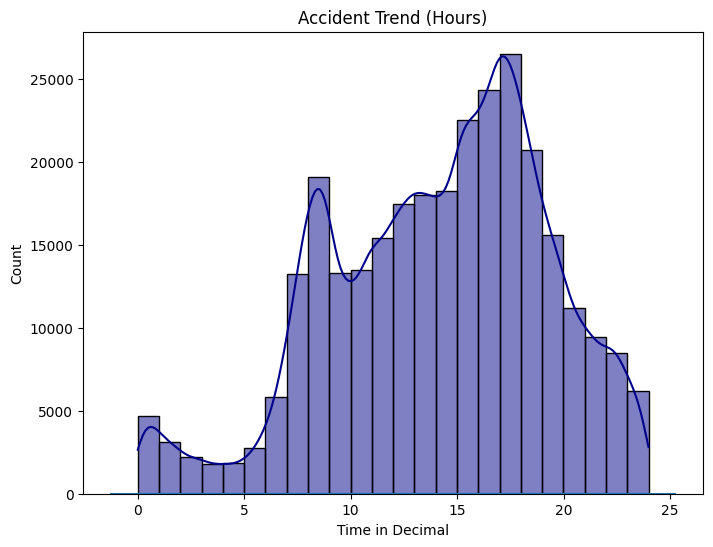

In [44]:
hist_gen(merged_data['decimal_time'],'Accident Trend (Hours)','Count', 'Time in Decimal', 1, kde=True, color='#00008B')

From the above, the hour of the day that accidents occur the most is 18:00

In [45]:
# Statistical info

merged_data['decimal_time'].describe()

count    295579.000000
mean         14.109474
std           5.141660
min           0.000000
25%          10.450000
50%          14.833333
75%          17.833333
max          23.983333
Name: decimal_time, dtype: float64

In [46]:
time_df = merged_data['decimal_time'].value_counts()

hour_of_day = pd.DataFrame(time_df)

hour_of_day

,count
decimal_time,
17.000000,2890
17.500000,2490
16.500000,2419
16.000000,2282
18.000000,2266
...,...
4.633333,4
4.200000,4
4.800000,4


In [47]:
merged_data['day_of_week'].describe()

count    295579.000000
mean          4.114599
std           1.943276
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max           7.000000
Name: day_of_week, dtype: float64

In [48]:
# Days in Number: No 1 reps Sunday to No 6 which reps Friday

merged_data['day_of_week'].value_counts()

day_of_week
6    48048
5    44285
4    43739
3    43207
2    41261
7    40723
1    34316
Name: count, dtype: int64

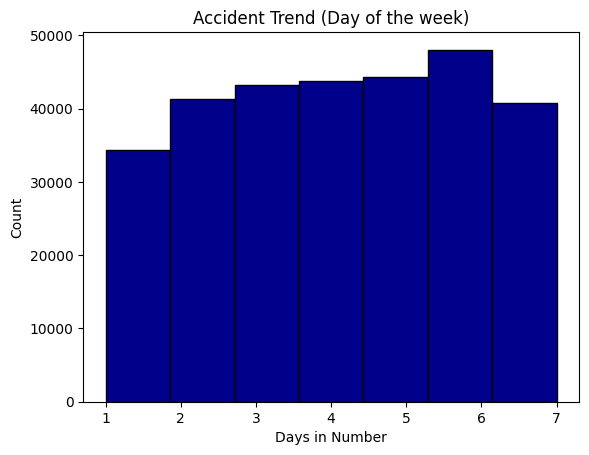

In [49]:
# Plotting a histogram showing this column

# Defining the data

day_of_week_data = merged_data['day_of_week']

# Calculating the number of unique days

num_days = len(day_of_week_data.unique())

plt.hist(day_of_week_data, bins=num_days, edgecolor='black', color='#00008B')

# Customize the plot
plt.title('Accident Trend (Day of the week)')
plt.xlabel('Days in Number')
plt.ylabel('Count')

# Show the plot
plt.show()

From the above, the day of the week that accidents occur the most No 6 which is Friday

In [50]:
# Location of most accidents occuring at 17:00 on Fridays 

merged_data.query('decimal_time == 18.0 and day_of_week == 6').local_authority_ons_district.value_counts()

local_authority_ons_district
E09000030    17
E09000006    10
E07000085     8
E08000019     7
E08000025     7
             ..
E07000086     1
E07000099     1
E08000012     1
E08000032     1
E06000018     1
Name: count, Length: 118, dtype: int64

In [51]:
# Obtaining further information on accident

info_df = merged_data.query('decimal_time == 18.0 and day_of_week == 6')

pd.DataFrame(info_df.groupby(['number_of_casualties', 'road_type', 'accident_severity', 'sex_of_driver', 'speed_limit', 'junction_detail', ]).local_authority_ons_district.value_counts().nlargest(1))

,,,,,,,count
number_of_casualties,road_type,accident_severity,sex_of_driver,speed_limit,junction_detail,local_authority_ons_district,
3,3,3,1,40,5,E09000030,6


In [52]:
# Obtaining further information on accident

info_df = merged_data.query('decimal_time == 18.0 and day_of_week == 6')

pd.DataFrame(info_df.groupby(['road_surface_conditions','light_conditions', 'special_conditions_at_site', 'weather_conditions']).local_authority_ons_district.value_counts().nlargest(1))

,,,,,count
road_surface_conditions,light_conditions,special_conditions_at_site,weather_conditions,local_authority_ons_district,
1,1,0,1,E09000030,12


In [53]:
# Total number of accidents occurring at this time and on friday

print(f'Accidents occuring at 18:00 and on a Friday was {len(info_df)}')

Accidents occuring at 18:00 and on a Friday was 351


## QUESTION 2

##### For motorbikes, are there significant hours of the day, and days of the week, on which accidents occur? We suggest a focus on: Motorcycle 125cc and under, Motorcycle over 125cc and up to 500cc, and Motorcycle over 500cc.

### Motorcycle 125cc and under

In [54]:
# From Accident Statistics Form

# M/cycle 50cc and under: 02 
# M/cycle over 50cc and up to 125cc: 03

M_125cc = merged_data[((merged_data['vehicle_type'] == 3) | (merged_data['vehicle_type'] == 2))]

M_125cc.decimal_time.value_counts()

decimal_time
17.000000    112
18.000000    106
17.500000    103
16.000000     89
15.500000     89
            ... 
0.066667       1
6.066667       1
19.783333      1
22.516667      1
1.416667       1
Name: count, Length: 1207, dtype: int64

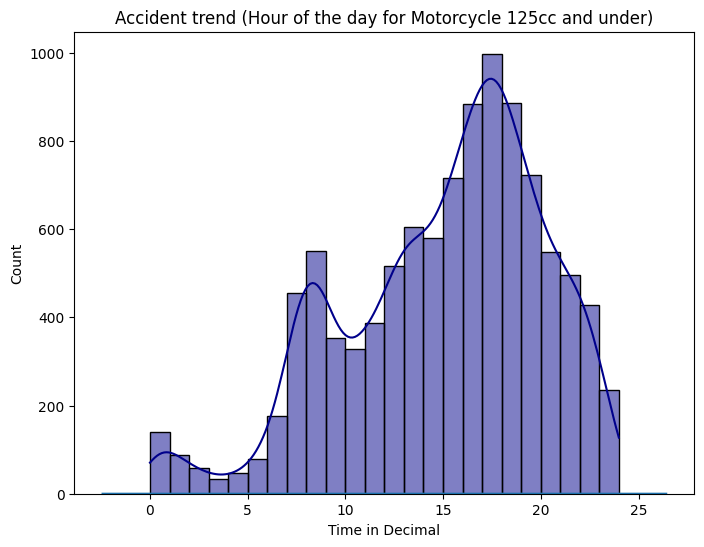

In [55]:
# Plotting histogram

hour_125cc = hist_gen(M_125cc['decimal_time'],'Accident trend (Hour of the day for Motorcycle 125cc and under)','Count', 'Time in Decimal', 1, kde=True, color='#00008B')

In [56]:
# Day of the week

M_125cc.day_of_week.value_counts()

day_of_week
6    1774
4    1606
5    1561
3    1551
2    1395
7    1296
1    1130
Name: count, dtype: int64

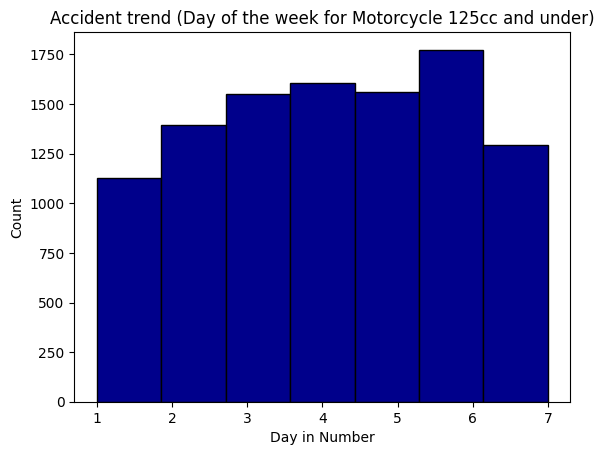

In [57]:
# Defining the data

week_125cc_data = M_125cc['day_of_week']

# Calculating the number of unique days

num_days = len(week_125cc_data.unique())

# Plotting the histogram with equally spaced bars

plt.hist(week_125cc_data, bins=num_days, edgecolor='black', color='#00008B')

# Customizing the plot

plt.title('Accident trend (Day of the week for Motorcycle 125cc and under)')
plt.xlabel('Day in Number')
plt.ylabel('Count')

# Show the plot
plt.show()

In [58]:
# Generate a dataframe for the above question to gain more insight

M_125cc_df = M_125cc.query('decimal_time == 17.0 and day_of_week == 6')

pd.DataFrame(M_125cc_df.groupby(['road_surface_conditions','light_conditions', 'special_conditions_at_site', 'weather_conditions']).local_authority_ons_district.value_counts().nlargest(1))

,,,,,count
road_surface_conditions,light_conditions,special_conditions_at_site,weather_conditions,local_authority_ons_district,
2,1,0,2,E09000019,2


In [59]:
# Obtaining further information on accident

M_125cc_df = M_125cc.query('decimal_time == 17.0 and day_of_week == 6')

pd.DataFrame(M_125cc_df.groupby(['number_of_casualties', 'road_type', 'accident_severity', 'sex_of_driver', 'speed_limit', 'junction_detail', ]).local_authority_ons_district.value_counts().nlargest(3))

count
number_of_casualties road_type accident_severity sex_of_driver speed_limit junction_detail local_authority_ons_district       
2                    2         3                 2             20          0               E09000019                         2
1                    1         3                 1             20          1               E09000009                         1
                     3         3                 1             40          6               E09000013                         1

In [60]:
print(f'Accidents at 17:00 and on a Friday was {len(M_125cc_df)}')

Accidents at 17:00 and on a Friday was 12


### Motorcycle over 125cc and up to 500cc

In [61]:
# From Accident Statistics Form

# M/cycle over 125cc and up to 500cc: 04 

M_500cc = merged_data[(merged_data['vehicle_type'] == 4)]

M_500cc.decimal_time.value_counts()

decimal_time
16.000000    33
17.000000    25
19.000000    24
18.500000    21
18.000000    21
             ..
9.600000      1
21.900000     1
0.600000      1
20.716667     1
10.183333     1
Name: count, Length: 720, dtype: int64

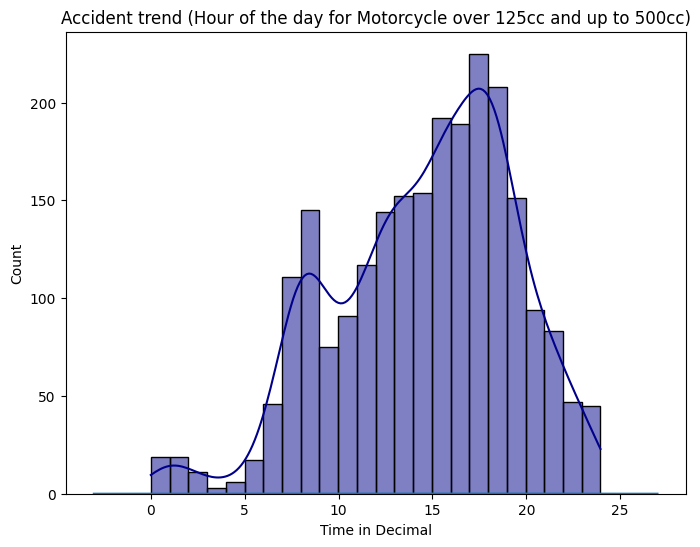

In [62]:
# Plotting histogram

hour_500cc = hist_gen(M_500cc['decimal_time'],'Accident trend (Hour of the day for Motorcycle over 125cc and up to 500cc)','Count', 'Time in Decimal', 1, kde=True, color='#00008B')

In [63]:
# Day of the week

M_500cc.day_of_week.value_counts()

day_of_week
6    375
5    374
4    339
3    337
1    317
2    314
7    288
Name: count, dtype: int64

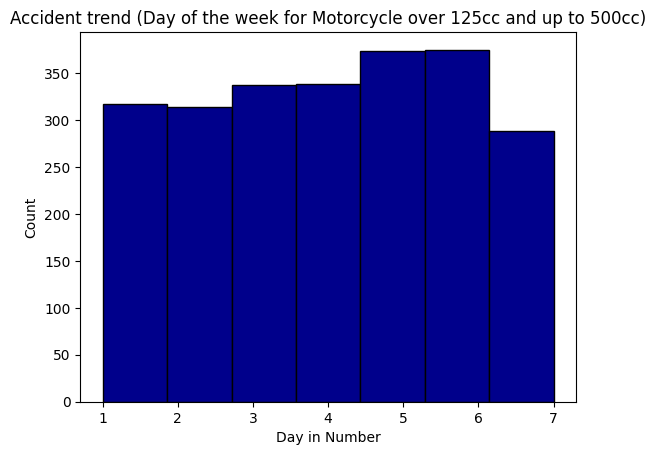

In [64]:
# Defining the data

week_500cc_data = M_500cc['day_of_week']

# Calculating the number of unique days

num_days = len(week_500cc_data.unique())

# Plotting the histogram with equally spaced bars

plt.hist(week_500cc_data, bins=num_days, edgecolor='black', color='#00008B')

# Customizing the plot

plt.title('Accident trend (Day of the week for Motorcycle over 125cc and up to 500cc)')
plt.xlabel('Day in Number')
plt.ylabel('Count')

# Showing the plot

plt.show()

In [65]:
# Generate a dataframe for the above question to gain more insight

M_500cc_df = M_500cc.query('decimal_time == 17.0 and day_of_week == 6')

pd.DataFrame(M_500cc_df.groupby(['road_surface_conditions','light_conditions', 'special_conditions_at_site', 'weather_conditions']).local_authority_ons_district.value_counts().nlargest(3))

count
road_surface_conditions light_conditions special_conditions_at_site weather_conditions local_authority_ons_district       
1                       1                0                          1                  E06000054                         1
                                                                                       E08000032                         1
                                                                                       E09000006                         1

In [66]:
# Obtaining further information on accident

M_500cc_df = M_500cc.query('decimal_time == 17.0 and day_of_week == 6')

pd.DataFrame(M_500cc_df.groupby(['number_of_casualties', 'road_type', 'accident_severity', 'sex_of_driver', 'speed_limit', 'junction_detail', ]).local_authority_ons_district.value_counts().nlargest(3))

count
number_of_casualties road_type accident_severity sex_of_driver speed_limit junction_detail local_authority_ons_district       
1                    3         3                 2             30          7               E07000154                         1
                     6         2                 1             20          3               E09000006                         1
                               3                 1             30          1               E06000054                         1

In [67]:
print(f'Accidents at 17:00 and on a Friday were {len(M_500cc_df)}')

Accidents at 17:00 and on a Friday were 6


### Motorcycle over 500cc 

In [68]:
# From Accident Statistics Form

# M/cycle over 500cc: 05

over_500cc = merged_data[(merged_data['vehicle_type'] == 5)]

over_500cc.decimal_time.value_counts()

decimal_time
13.000000    70
17.000000    61
15.000000    57
17.500000    57
15.500000    53
             ..
8.883333      1
19.733333     1
19.150000     1
6.766667      1
9.483333      1
Name: count, Length: 999, dtype: int64

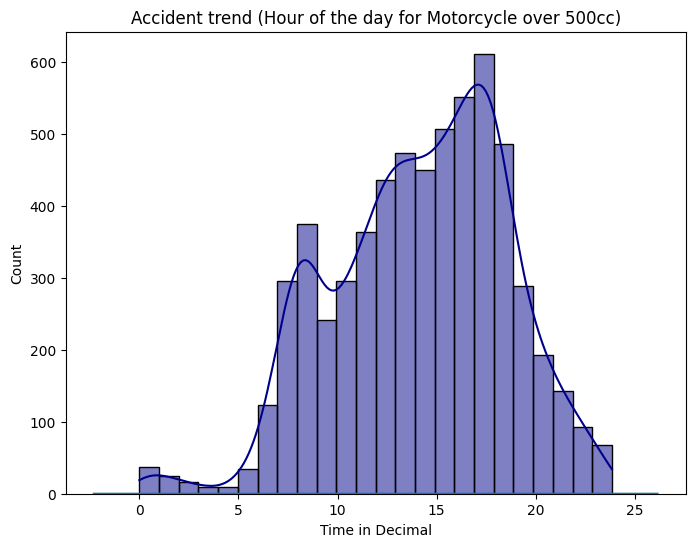

In [69]:
# Plotting histogram

hour_over_500cc = hist_gen(over_500cc['decimal_time'],'Accident trend (Hour of the day for Motorcycle over 500cc)','Count', 'Time in Decimal', 1, kde=True, color='#00008B')

In [70]:
# Day of the week

over_500cc.day_of_week.value_counts()

day_of_week
1    1042
7     984
6     869
5     850
4     842
3     797
2     735
Name: count, dtype: int64

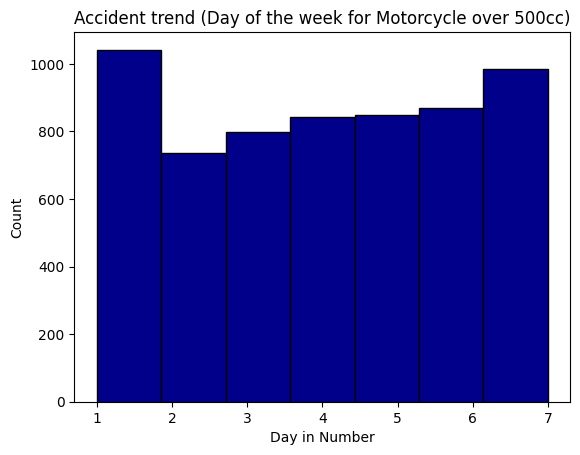

In [71]:
# Defining the data

week_over_500cc_data = over_500cc['day_of_week']

# Calculating the number of unique days

num_days = len(week_over_500cc_data.unique())

# Plotting the histogram with equally spaced bars

plt.hist(week_over_500cc_data, bins=num_days, edgecolor='black', color='#00008B')

# Customizing the plot

plt.title('Accident trend (Day of the week for Motorcycle over 500cc)')
plt.xlabel('Day in Number')
plt.ylabel('Count')

# Showing the plot

plt.show()

In [72]:
# Generate a dataframe for the above question to gain more insight

over_500cc_df = over_500cc.query('decimal_time == 17 and day_of_week == 1')

pd.DataFrame(over_500cc_df.groupby(['road_surface_conditions','light_conditions', 'special_conditions_at_site', 'weather_conditions']).local_authority_ons_district.value_counts().nlargest(1))

,,,,,count
road_surface_conditions,light_conditions,special_conditions_at_site,weather_conditions,local_authority_ons_district,
1,1,0,1,E06000046,2


In [73]:
# Obtaining further information on accident

over_500cc_df = over_500cc.query('decimal_time == 17.0 and day_of_week == 1')

pd.DataFrame(over_500cc_df.groupby(['number_of_casualties', 'road_type', 'accident_severity', 'sex_of_driver', 'speed_limit', 'junction_detail', ]).local_authority_ons_district.value_counts().nlargest(1))

,,,,,,,count
number_of_casualties,road_type,accident_severity,sex_of_driver,speed_limit,junction_detail,local_authority_ons_district,
2,3,2,1,40,1,E07000199,2


In [74]:
print(f'Accidents at 17:00 and on a Friday were {len(over_500cc_df)}')

Accidents at 17:00 and on a Friday were 7


## QUESTION 3

##### For pedestrians involved in accidents, are there significant hours of the day, and days of the week, on which they are more likely to be involved?

In [75]:
# From Accident Statistics Form
# Pedestrian in casualty class : 3

merged_data[merged_data['casualty_class'] == 3].casualty_class.count()

23538

In [76]:
merged_data[merged_data['casualty_class'] == 3].decimal_time.value_counts()

decimal_time
15.500000    339
16.000000    244
17.000000    234
8.500000     221
16.500000    217
            ... 
4.483333       1
6.783333       1
4.616667       1
4.750000       1
5.066667       1
Name: count, Length: 1337, dtype: int64

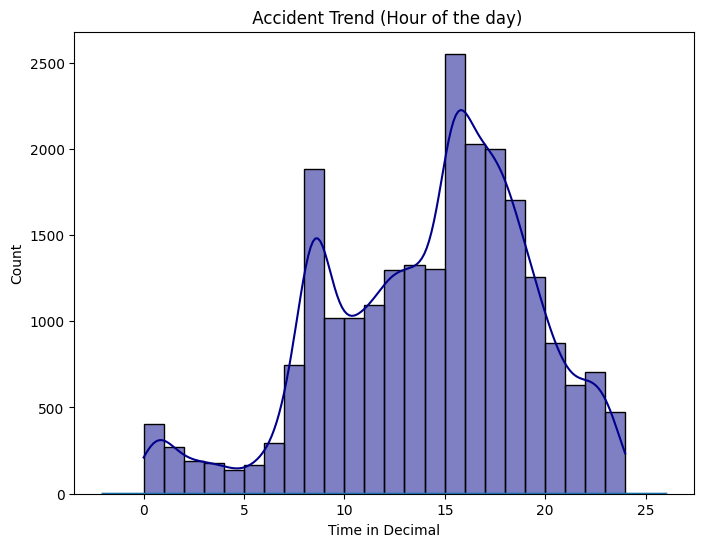

In [77]:
# Plotting a histogram showing this column

pedestrian_image_hour = hist_gen(merged_data[merged_data['casualty_class'] == 3].decimal_time,' Accident Trend (Hour of the day)','Count', 'Time in Decimal', 1, kde=True, color='#00008B')

In [78]:
# Day of the week

merged_data[merged_data['casualty_class'] == 3].day_of_week.value_counts()

day_of_week
6    3932
5    3746
3    3620
4    3591
2    3366
7    3103
1    2180
Name: count, dtype: int64

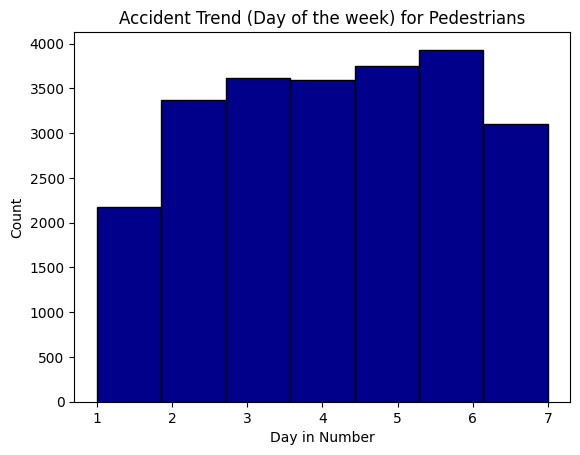

In [79]:
# Filtering data for pedestrians

pedestrian_data = merged_data[merged_data['casualty_class'] == 3]['day_of_week']

# Calculating the number of unique days

num_days = len(pedestrian_data.unique())

# Plotting the histogram with equally spaced bars

plt.hist(pedestrian_data, bins=num_days, edgecolor='black', color='#00008B')

# Customizing the plot

plt.title('Accident Trend (Day of the week) for Pedestrians')
plt.xlabel('Day in Number')
plt.ylabel('Count')

# Showing the plot
plt.show()

In [80]:
# For more information

pedestrian_df = merged_data.query('casualty_class == 3 and decimal_time == 15.5 and day_of_week == 6')

pd.DataFrame(pedestrian_df.groupby(['road_surface_conditions','light_conditions', 'special_conditions_at_site', 'weather_conditions']).local_authority_ons_district.value_counts().nlargest(1))

,,,,,count
road_surface_conditions,light_conditions,special_conditions_at_site,weather_conditions,local_authority_ons_district,
1,1,0,1,E08000026,3


In [81]:
# Obtaining further information on accident

pedestrian_df = merged_data.query('casualty_class == 3 and decimal_time == 15.5 and day_of_week == 6')

pd.DataFrame(pedestrian_df.groupby(['accident_severity', 'speed_limit', 'junction_detail', 'sex_of_driver']).local_authority_ons_district.value_counts().nlargest(1))

,,,,,count
accident_severity,speed_limit,junction_detail,sex_of_driver,local_authority_ons_district,
3,30,0,2,E06000015,2


In [82]:
# Total number of accidents occurring at this time and on friday

print(f'Accidents at 15:30 and on a Friday were {len(pedestrian_df)}')

Accidents at 15:30 and on a Friday were 60


## QUESTION 4

##### Using the apriori algorithm, explore the impact of selected variables on accident severity.  

In [83]:
# Selecting columns

sel_columns = merged_data.select_dtypes(include=['int32', 'float64'])  # Selecting only numerical columns
correlation_matrix = sel_columns.corr()

In [84]:
severity_1 = merged_data[merged_data['accident_severity'] == 1]
severity_2 = merged_data[merged_data['accident_severity'] == 2]
severity_3 = merged_data[merged_data['accident_severity'] == 3]


In [85]:
# Checking the variable influence

severity_corr1 = sel_columns.corrwith(merged_data['accident_severity'].where(merged_data['accident_severity'] == 1).fillna(0))
severity_corr2 = sel_columns.corrwith(merged_data['accident_severity'].where(merged_data['accident_severity'] == 2).fillna(0))
severity_corr3 = sel_columns.corrwith(merged_data['accident_severity'].where(merged_data['accident_severity'] == 3).fillna(0))

In [86]:
# Creating pandas dataframes to store results

severity_corr1_df = pd.DataFrame({'Variable': severity_corr1.index, 'Correlation': severity_corr1.values})
severity_corr2_df = pd.DataFrame({'Variable': severity_corr2.index, 'Correlation': severity_corr2.values})
severity_corr3_df = pd.DataFrame({'Variable': severity_corr3.index, 'Correlation': severity_corr3.values})

In [87]:
# Printing  top 10 correlated features for each severity level

print("Top 10 features that correlate with accident_severity = 1:\n", severity_corr1_df.nlargest(10, 'Correlation'))
print("\nTop 10 features that correlate with accident_severity = 2:\n", severity_corr2_df.nlargest(10, 'Correlation'))
print("\nTop 10 features that correlate with accident_severity = 3:\n", severity_corr3_df.nlargest(10, 'Correlation'))

Top 10 features that correlate with accident_severity = 1:
                        Variable  Correlation
8          number_of_casualties     0.126513
14                  speed_limit     0.112152
26          urban_or_rural_area     0.097981
41  vehicle_leaving_carriageway     0.063182
7            number_of_vehicles     0.059546
4                      latitude     0.054066
2        location_northing_osgr     0.054039
34            vehicle_manoeuvre     0.052990
62         age_band_of_casualty     0.043751
61              age_of_casualty     0.043278

Top 10 features that correlate with accident_severity = 2:
                        Variable  Correlation
8          number_of_casualties     0.112238
26          urban_or_rural_area     0.096854
14                  speed_limit     0.083873
34            vehicle_manoeuvre     0.075463
5                  police_force     0.068678
10     local_authority_district     0.068336
41  vehicle_leaving_carriageway     0.066752
29                vehicl

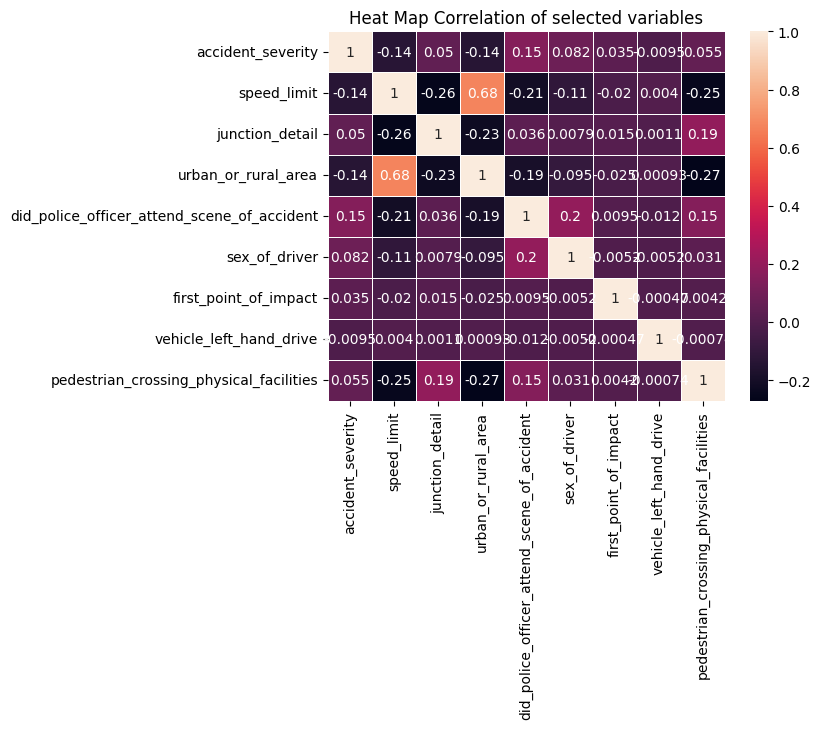

In [88]:
# Generating heatmap from common variables from the list of correlated values

selected_data = merged_data[['accident_severity', 'speed_limit', 'junction_detail', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident','sex_of_driver','first_point_of_impact',
                'vehicle_left_hand_drive', 'pedestrian_crossing_physical_facilities', ]]
sns.heatmap(selected_data.corr(),annot=True, linewidths=0.5 )
plt.title("Heat Map Correlation of selected variables")
plt.xticks(rotation=90);

In [89]:
accident_apriori = merged_data[['accident_severity', 'speed_limit', 'junction_detail', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident','sex_of_driver','first_point_of_impact',
                'vehicle_left_hand_drive', 'pedestrian_crossing_physical_facilities']]

# One-hot encoding 

as_encode = pd.get_dummies(accident_apriori.accident_severity, prefix='severity')
sl_encode = pd.get_dummies(accident_apriori.speed_limit, prefix='speed')
jd_encode = pd.get_dummies(accident_apriori.junction_detail, prefix='junction')
uora_encode = pd.get_dummies(accident_apriori.urban_or_rural_area, prefix='area')
dpoasoa_encode = pd.get_dummies(accident_apriori.did_police_officer_attend_scene_of_accident, prefix='police')
sod_encode = pd.get_dummies(accident_apriori.sex_of_driver, prefix='driver')
fpoi_encode =  pd.get_dummies(accident_apriori.first_point_of_impact, prefix='impact')
vlhd_encode = pd.get_dummies(accident_apriori.vehicle_left_hand_drive, prefix='vehicle')
pcpf_encode = pd.get_dummies(accident_apriori.pedestrian_crossing_physical_facilities, prefix='pedestrian')

In [90]:
apriori_merge = pd.concat([as_encode, sl_encode, jd_encode, uora_encode, dpoasoa_encode, sod_encode, fpoi_encode, vlhd_encode, pcpf_encode], axis=1)

In [91]:
# Calculating support

support = apriori(apriori_merge, min_support=0.02, use_colnames=True)

support.head(10)

,support,itemsets
0,0.200484,(severity_2)
1,0.779856,(severity_3)
2,0.080371,(speed_20)
3,0.539013,(speed_30)
4,0.096536,(speed_40)
5,0.050768,(speed_50)
6,0.142030,(speed_60)
7,0.091282,(speed_70)
8,0.432280,(junction_0)
9,0.074383,(junction_1)


In [95]:
# Creating a class to estimate the metrics of interest

class AprioriMetrics:
    def __init__(self, table, metric, threshold_min):
        self.table = table
        self.metric = metric
        self.threshold_min = threshold_min

    def metric_estimate(self):
        new_rule = association_rules(
            self.table,
            metric=self.metric,
            min_threshold=self.threshold_min
        )
        return new_rule

        
conf = AprioriMetrics(support, 'confidence', 0.2)
confidence = conf.metric_estimate()
print(confidence)


                                  antecedents  \
0                                (severity_2)   
1                                  (speed_40)   
2                                  (speed_60)   
3                                (severity_2)   
4                                (junction_0)   
...                                       ...   
71234        (speed_30, junction_3, driver_1)   
71235  (pedestrian_0, junction_3, impact_1.0)   
71236    (junction_3, impact_1.0, severity_3)   
71237      (driver_1, junction_3, impact_1.0)   
71238      (police_1, junction_3, impact_1.0)   

                                             consequents  antecedent support  \
0                                             (speed_30)            0.200484   
1                                           (severity_2)            0.096536   
2                                           (severity_2)            0.142030   
3                                             (speed_60)            0.200484   
4          

In [96]:
class confidence_severity:
    def __init__(self, table, name_col):
        self.table = table # dataframe
        self.name_col = name_col #Column name
    def severity(self):
        # Create an empty list
        new_list = []

        #Iterate thru the confidence table
        for i, j in self.table.iterrows(): 

            #Create an empty list
            severity = []
            for p in list(j[self.name_col]):
               # if severity is contained in column consequent, append true to the empty list 
                if 'severity' in p:
                    severity.append(True)
                else:
                    severity.append(False)
            if True in severity:
                new_list.append(True)
            else:
                new_list.append(False)
        return new_list

s = confidence_severity(confidence, 'consequents')
severity_list = s.severity()

In [97]:
# Calling the class

confidence['severity'] = severity_list
new = confidence[confidence.severity == True]

new.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,severity
1,(speed_40),(severity_2),0.096536,0.200484,0.020171,0.208944,1.042194,1.0,0.000817,1.010694,0.044812,0.072857,0.010580,0.154776,True
2,(speed_60),(severity_2),0.142030,0.200484,0.042662,0.300374,1.498241,1.0,0.014187,1.142776,0.387601,0.142277,0.124938,0.256584,True
4,(junction_0),(severity_2),0.432280,0.200484,0.097801,0.226245,1.128491,1.0,0.011136,1.033293,0.200559,0.182819,0.032220,0.357035,True
8,(area_2),(severity_2),0.375619,0.200484,0.094164,0.250691,1.250427,1.0,0.018859,1.067004,0.320755,0.195386,0.062797,0.360188,True
10,(police_1),(severity_2),0.734146,0.200484,0.170628,0.232417,1.159276,1.0,0.023443,1.041601,0.516797,0.223334,0.039940,0.541747,True
12,(driver_1),(severity_2),0.626009,0.200484,0.137621,0.219839,1.096541,1.0,0.012116,1.024809,0.235411,0.199778,0.024208,0.453142,True
15,(impact_1.0),(severity_2),0.506409,0.200484,0.113053,0.223244,1.113521,1.0,0.011525,1.029300,0.206543,0.190375,0.028466,0.393571,True
17,(impact_3.0),(severity_2),0.128554,0.200484,0.027671,0.215248,1.073640,1.0,0.001898,1.018813,0.078707,0.091818,0.018466,0.176635,True
18,(impact_4.0),(severity_2),0.107585,0.200484,0.022180,0.206164,1.028327,1.0,0.000611,1.007154,0.030867,0.077583,0.007103,0.158398,True
19,(vehicle_1.0),(severity_2),0.951556,0.200484,0.197446,0.207498,1.034985,1.0,0.006674,1.008850,0.697762,0.206838,0.008773,0.596172,True


In [99]:
lift = AprioriMetrics(support, 'lift', 0.5)
lift = lift.metric_estimate()
lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(speed_30),(severity_2),0.539013,0.200484,0.095873,0.177867,0.887188,1.0,-0.012191,0.972490,-0.216201,0.148958,-0.028289,0.328037
1,(severity_2),(speed_30),0.200484,0.539013,0.095873,0.478206,0.887188,1.0,-0.012191,0.883465,-0.137219,0.148958,-0.131907,0.328037
2,(speed_40),(severity_2),0.096536,0.200484,0.020171,0.208944,1.042194,1.0,0.000817,1.010694,0.044812,0.072857,0.010580,0.154776
3,(severity_2),(speed_40),0.200484,0.096536,0.020171,0.100609,1.042194,1.0,0.000817,1.004529,0.050638,0.072857,0.004508,0.154776
4,(speed_60),(severity_2),0.142030,0.200484,0.042662,0.300374,1.498241,1.0,0.014187,1.142776,0.387601,0.142277,0.124938,0.256584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129673,(pedestrian_0),"(junction_3, vehicle_1.0, area_1, speed_30, se...",0.806654,0.031514,0.023601,0.029258,0.928402,1.0,-0.001820,0.997676,-0.285135,0.028974,-0.002330,0.389079
129674,(severity_3),"(junction_3, vehicle_1.0, area_1, speed_30, pe...",0.779856,0.031240,0.023601,0.030263,0.968729,1.0,-0.000762,0.998993,-0.127882,0.029970,-0.001008,0.392866
129675,(impact_1.0),"(junction_3, vehicle_1.0, area_1, speed_30, pe...",0.506409,0.041353,0.023601,0.046605,1.127008,1.0,0.002660,1.005509,0.228316,0.045026,0.005479,0.308666
129676,(driver_1),"(junction_3, vehicle_1.0, area_1, speed_30, pe...",0.626009,0.036315,0.023601,0.037701,1.038161,1.0,0.000868,1.001440,0.098286,0.036951,0.001438,0.343799


## QUESTION 5

##### Identify accidents in our region: Kingston upon Hull, Humberside, and the East Riding of Yorkshire etc. You can do this by filtering on LSOA, or police region or another method if you can find one. Run clustering on this data. What do these clusters reveal about the distribution of accidents in our region? 

### 1. Kingston Upon Hull

In [100]:
# Filtering out kingston upon hull (Kingston upon Hull = 'E06000010')

kingston = merged_data[merged_data.local_authority_ons_district == 'E06000010']

In [101]:
# Day of the week of most occuring accidents

kingston.groupby('day_of_week').size().sort_values(ascending=False)  

day_of_week
4    293
2    278
6    273
5    271
3    261
1    187
7    187
dtype: int64

In [102]:
# Time of most occuring accidents

kingston.groupby('decimal_time').size().sort_values(ascending=False)  

decimal_time
15.000000    27
16.000000    25
17.166667    17
18.500000    17
12.000000    17
             ..
12.333333     1
12.300000     1
11.616667     1
11.483333     1
23.783333     1
Length: 448, dtype: int64

In [103]:
# Percentage of accidents 

total_accidents = len(merged_data)

len_kingston = len(kingston)

percentage_kingston = (len_kingston/total_accidents)*100

print(f'The total number of accidents that occurred in Kingston Upon Hull were {len_kingston}, which is {percentage_kingston:.2f}% of the total accidents')

The total number of accidents that occurred in Kingston Upon Hull were 1750, which is 0.59% of the total accidents


In [104]:
# Fatal accidents in Kingston. accident_severity == 1

kingston[merged_data.accident_severity == 1].accident_severity.count()

13

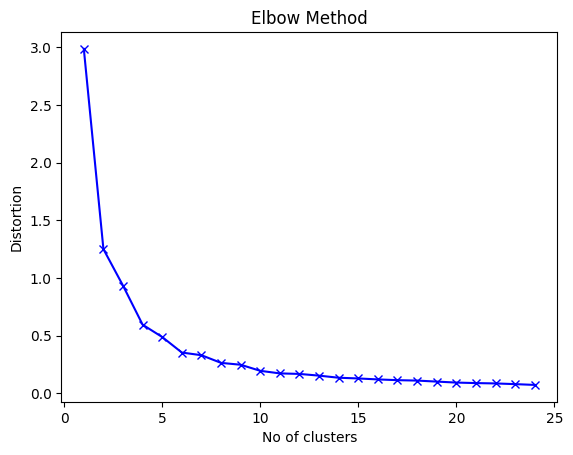

In [105]:
# Filtering the data

kingston = merged_data[merged_data.local_authority_ons_district == 'E06000010']

# Estimating K value
dist = []
K = range(1, 25)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(kingston[['longitude', 'latitude']])
    dist.append(kmeans.inertia_)

plt.plot(K, dist, 'bx-')
plt.xlabel('No of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method')
plt.show()

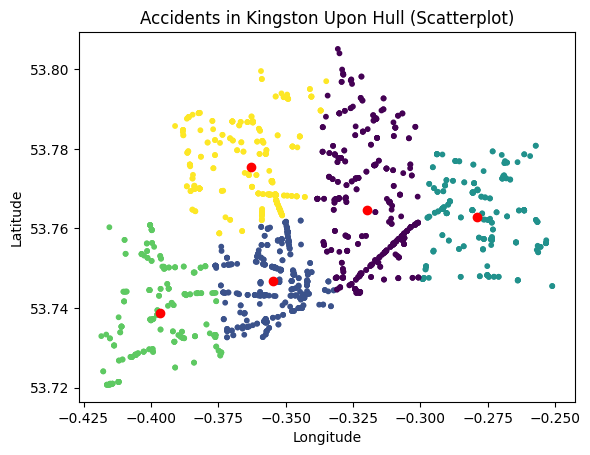

In [106]:
# Filtering the data
kingston = merged_data[merged_data.local_authority_ons_district == 'E06000010']

# Using Kmeans clustering

kmeans = KMeans(n_clusters=5)
kmeans.fit(kingston[['longitude', 'latitude']])

labels = kmeans.predict(kingston[['longitude', 'latitude']])
centroids = kmeans.cluster_centers_

plt.scatter(kingston['longitude'], kingston['latitude'], c=labels, cmap='viridis', s=10)
plt.scatter(centroids[:, 0], centroids[:, 1], color='red')

plt.title('Accidents in Kingston Upon Hull (Scatterplot)')
plt.ylabel('Latitude')
plt.xlabel('Longitude')

plt.show()

In [107]:
# Filtering data for Kingston Upon Hull

kingston = merged_data[merged_data.local_authority_ons_district == 'E06000010']

# Performing KMeans clustering

kmeans = KMeans(n_clusters=5)
kingston['label'] = kmeans.fit_predict(kingston[['longitude', 'latitude']])

# Calculating mean latitude and longitude

lat_mean, long_mean = kingston[['latitude', 'longitude']].mean()

# Creating a folium map centered at the mean latitude and longitude

kingston_map = folium.Map(location=[lat_mean, long_mean], zoom_start=10)

# Adding marker cluster to the map

marker_cluster = folium.plugins.MarkerCluster().add_to(kingston_map)

# Adding markers for each data point

for _, row in kingston.iterrows():
    folium.Marker([row['latitude'], row['longitude']], popup=str(row['label'])).add_to(marker_cluster)

# Saving the map as an HTML file

kingston_map.save('kingston_map.html')

### 2. East Riding of Yorkshire

In [108]:
# Filtering out East Riding of Yorkshire (East Riding of Yorkshire = 'E06000011')

yorkshire = merged_data[merged_data.local_authority_ons_district == 'E06000011']

In [109]:
# Day of the week of most occuring accidents

yorkshire.groupby('day_of_week').size().sort_values(ascending=False)  

day_of_week
6    334
5    282
4    265
3    263
7    238
2    235
1    182
dtype: int64

In [110]:
# Time of most occuring accidents

yorkshire.groupby('decimal_time').size().sort_values(ascending=False)  

decimal_time
15.750000    27
17.000000    25
16.500000    25
16.833333    24
13.666667    24
             ..
9.083333      1
9.483333      1
18.266667     1
10.183333     1
23.983333     1
Length: 402, dtype: int64

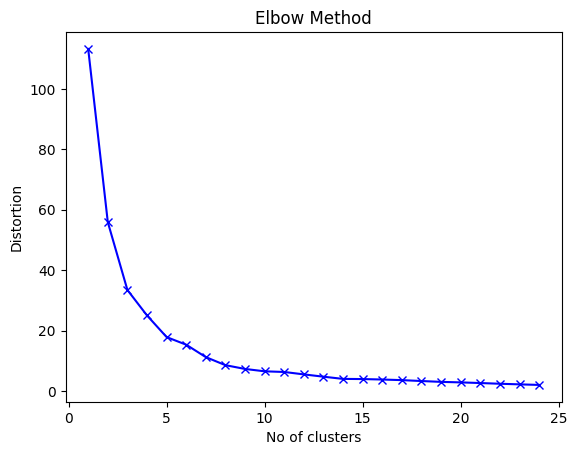

In [111]:
# Filtering the data

yorkshire = merged_data[merged_data.local_authority_ons_district == 'E06000011']

# Estimating K value
dist = []
K = range(1, 25)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(yorkshire[['longitude', 'latitude']])
    dist.append(kmeans.inertia_)

plt.plot(K, dist, 'bx-')
plt.xlabel('No of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method')
plt.show()

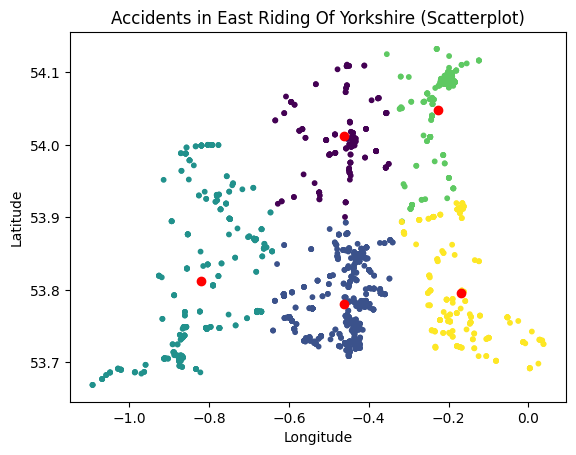

In [112]:
# Filtering the data

yorkshire = merged_data[merged_data.local_authority_ons_district == 'E06000011']

# Using Kmeans clustering

kmeans = KMeans(n_clusters=5)
kmeans.fit(yorkshire[['longitude', 'latitude']])

labels = kmeans.predict(yorkshire[['longitude', 'latitude']])
centroids = kmeans.cluster_centers_

plt.scatter(yorkshire['longitude'], yorkshire['latitude'], c=labels, cmap='viridis', s=10)
plt.scatter(centroids[:, 0], centroids[:, 1], color='red')

plt.title('Accidents in East Riding Of Yorkshire (Scatterplot)')
plt.ylabel('Latitude')
plt.xlabel('Longitude')

plt.show()

In [113]:
# Filtering data for East Riding Of Yorkshire

yorkshire = merged_data[merged_data.local_authority_ons_district == 'E06000011']

# Performing KMeans clustering

kmeans = KMeans(n_clusters=5)
yorkshire['label'] = kmeans.fit_predict(yorkshire[['longitude', 'latitude']])

# Calculating mean latitude and longitude

lat_mean, long_mean = yorkshire[['latitude', 'longitude']].mean()

# Creating a folium map centered at the mean latitude and longitude

yorkshire_map = folium.Map(location=[lat_mean, long_mean], zoom_start=10)

# Adding marker cluster to the map

marker_cluster = folium.plugins.MarkerCluster().add_to(yorkshire_map)

# Adding markers for each data point

for _, row in yorkshire.iterrows():
    folium.Marker([row['latitude'], row['longitude']], popup=str(row['label'])).add_to(marker_cluster)

# Saving the map as an HTML file

yorkshire_map.save('yorkshire_map.html')

## Question # 6

##### Choose three policing areas by filtering the data using the "police_force" column, then create a separate time series model for each policing area chosen to predict weekly accident counts for 2019 based on historical data from 2017 to 2018.

In [168]:
def dataframe_generator(y, accident_year=False):
    import sqlite3
    import pandas as pd
    
    # Open database connection
    con = sqlite3.connect("accident_data_v1.0.0_2023.db")
    cur = con.cursor()
    
    # Get column names
    col_info = cur.execute(f"PRAGMA table_info('{y}')").fetchall()
    y_cols = [i[1] for i in col_info]
    
    # Fetch data
    if accident_year:
        res = cur.execute(f"SELECT * FROM '{y}' WHERE accident_year = 2019").fetchall()
    else:
        res = cur.execute(f"SELECT * FROM '{y}'").fetchall()
    
    # Create DataFrame
    y_df = pd.DataFrame(res, columns=y_cols)
    
    # Close connection
    con.close()
    
    return y_df


In [169]:
# Generate historical data (all years)
accident_hist = dataframe_generator('accident', accident_year=False)
vehicle_hist = dataframe_generator('vehicle', accident_year=False)
casualty_hist = dataframe_generator('casualty', accident_year=False)

# Convert date to datetime
accident_hist['date'] = pd.to_datetime(accident_hist['date'], errors='coerce')

# Filter only 2017 and 2018
accident_hist = accident_hist[accident_hist['date'].dt.year.isin([2017, 2018])]

# Merge datasets like you did for 2019
merged_hist = accident_hist.merge(vehicle_hist, on='accident_index', how='inner') \
                           .merge(casualty_hist, on='accident_index', how='inner')

print(f"Historical merged data: {len(merged_hist)} records (2017-2018)")


Historical merged data: 252748 records (2017-2018)


In [170]:
# Choose three forces (example: 1, 20, 46)
selected_forces = [1, 20, 46]

# Filter historical data
hist_filtered = merged_hist[merged_hist['police_force'].isin(selected_forces)].copy()
print(hist_filtered['police_force'].value_counts())


police_force
1     45290
20    11780
46    10020
Name: count, dtype: int64


In [171]:
def create_weekly_series(data, force_id):
    force_data = data[data['police_force'] == force_id].copy()
    force_data.set_index('date', inplace=True)
    weekly_data = force_data.resample('W').size()
    weekly_data.name = 'accidents'
    print(f"Force {force_id}: {len(weekly_data)} weeks, {weekly_data.sum()} total accidents")
    return weekly_data

weekly_series = {force: create_weekly_series(hist_filtered, force) for force in selected_forces}


Force 1: 103 weeks, 45290 total accidents
Force 20: 103 weeks, 11780 total accidents
Force 46: 103 weeks, 10020 total accidents


In [172]:
# Make sure you have 2019 merged_data already from previous questions
# merged_data is your 2019 dataset

train_data, test_data = {}, {}
for force in selected_forces:
    # Training: historical weekly series
    train_data[force] = weekly_series[force]
    
    # Test: 2019 weekly series from your merged_data
    test_force = merged_data[merged_data['police_force'] == force].copy()
    test_force.set_index('date', inplace=True)
    test_weekly = test_force.resample('W').size()
    test_data[force] = test_weekly
    print(f"Force {force}: Train weeks={len(train_data[force])}, Test weeks={len(test_data[force])}")


Force 1: Train weeks=103, Test weeks=53
Force 20: Train weeks=103, Test weeks=53
Force 46: Train weeks=103, Test weeks=53


In [173]:
def fit_arima_model(series):
    best_aic = float('inf')
    best_model = None
    best_order = None
    for p in [0,1,2]:
        for d in [0,1]:
            for q in [0,1,2]:
                try:
                    model = ARIMA(series, order=(p,d,q)).fit()
                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_model = model
                        best_order = (p,d,q)
                except:
                    continue
    return best_model, best_order

models = {}
for force in selected_forces:
    model, order = fit_arima_model(train_data[force])
    models[force] = model
    print(f"Force {force}: Best ARIMA order {order}")


Force 1: Best ARIMA order (2, 0, 2)
Force 20: Best ARIMA order (2, 0, 2)
Force 46: Best ARIMA order (2, 0, 2)


In [174]:
predictions, ci_dict = {}, {}
for force in selected_forces:
    steps = len(test_data[force])
    forecast = models[force].get_forecast(steps=steps)
    predictions[force] = forecast.predicted_mean
    ci_dict[force] = forecast.conf_int()


In [176]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted)/np.maximum(actual,1))) * 100
    corr = np.corrcoef(actual, predicted)[0,1]
    return mae, rmse, mape, corr

results = []
for force in selected_forces:
    actual = test_data[force].values
    pred = predictions[force].values
    mae, rmse, mape, corr = evaluate(actual, pred)
    results.append({'force': force, 'MAE': mae, 'RMSE': rmse, 'MAPE%': mape, 'Correlation': corr})

results_df = pd.DataFrame(results).round(2)
print("\n=== MODEL PERFORMANCE ===")
print(results_df)



=== MODEL PERFORMANCE ===
   force     MAE       RMSE  MAPE%  Correlation
0      1  615.09  476815.47  57.96         0.11
1     20  166.23   39913.69  62.09         0.23
2     46  126.53   24090.07  60.01         0.25


In [178]:
comparison = []
for force in selected_forces:
    actual_total = test_data[force].sum()
    predicted_total = predictions[force].sum()
    diff = predicted_total - actual_total
    perc_diff = (diff / actual_total) * 100 if actual_total > 0 else 0
    comparison.append({
        'force': force,
        'actual_total': actual_total,
        'predicted_total': predicted_total,
        'difference': diff,
        'accuracy%': 100 - abs(perc_diff)
    })

comparison_df = pd.DataFrame(comparison).round(2)
print("\n*** TOTAL ACCIDENT COMPARISON 2019 ***")
print(comparison_df)



*** TOTAL ACCIDENT COMPARISON 2019 ***
   force  actual_total  predicted_total  difference  accuracy%
0      1         55059         22480.12   -32578.88      40.83
1     20         14486          5720.69    -8765.31      39.49
2     46         11465          4935.57    -6529.43      43.05


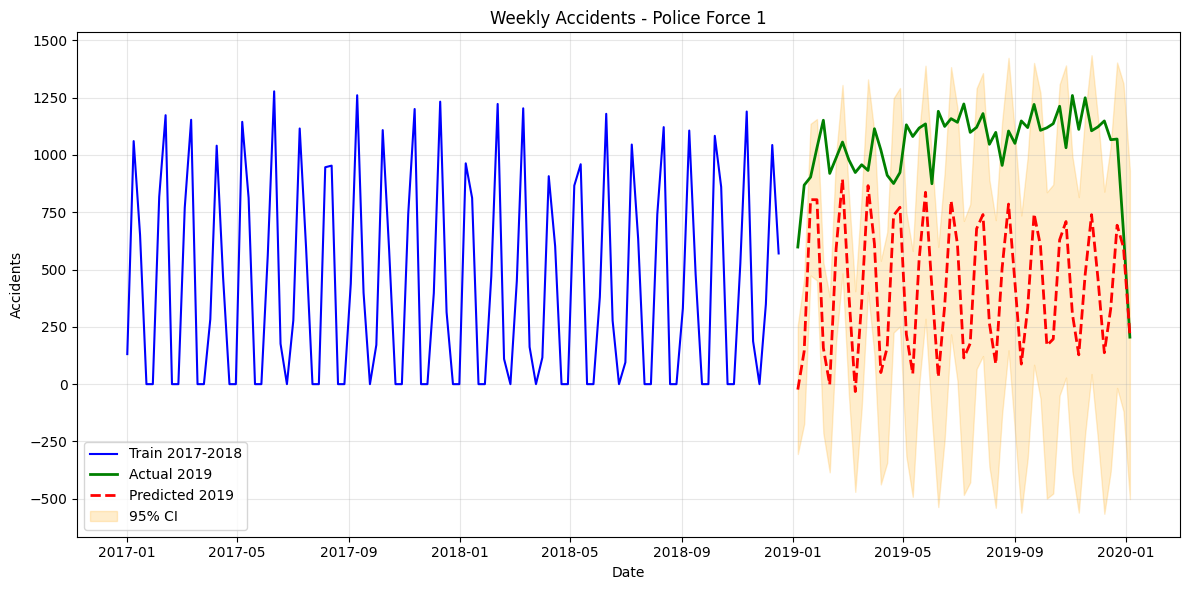

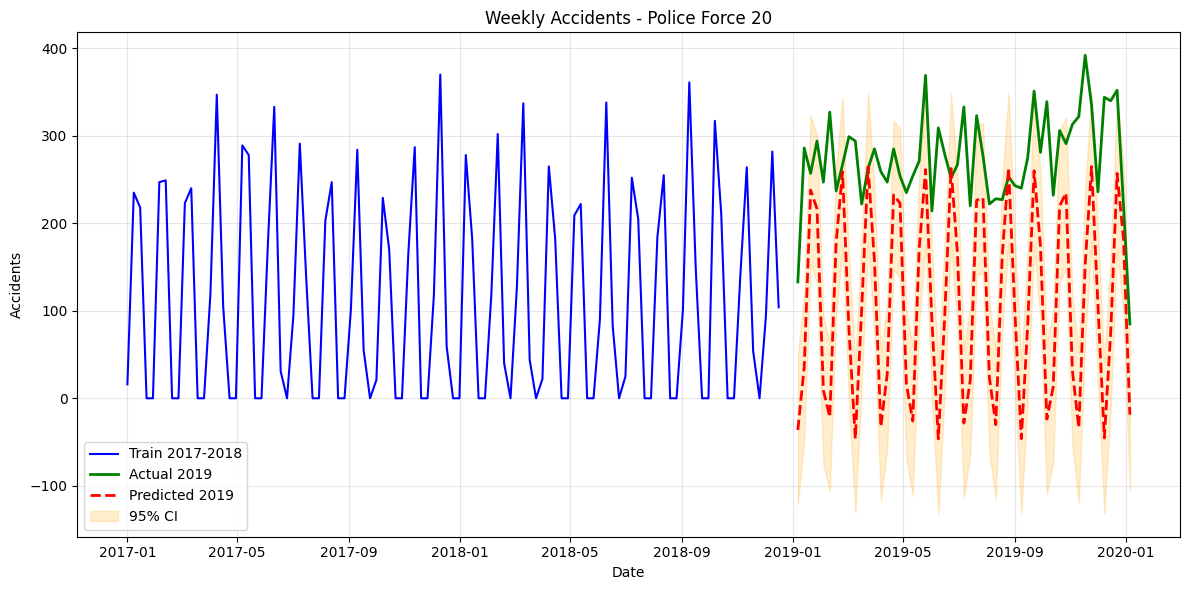

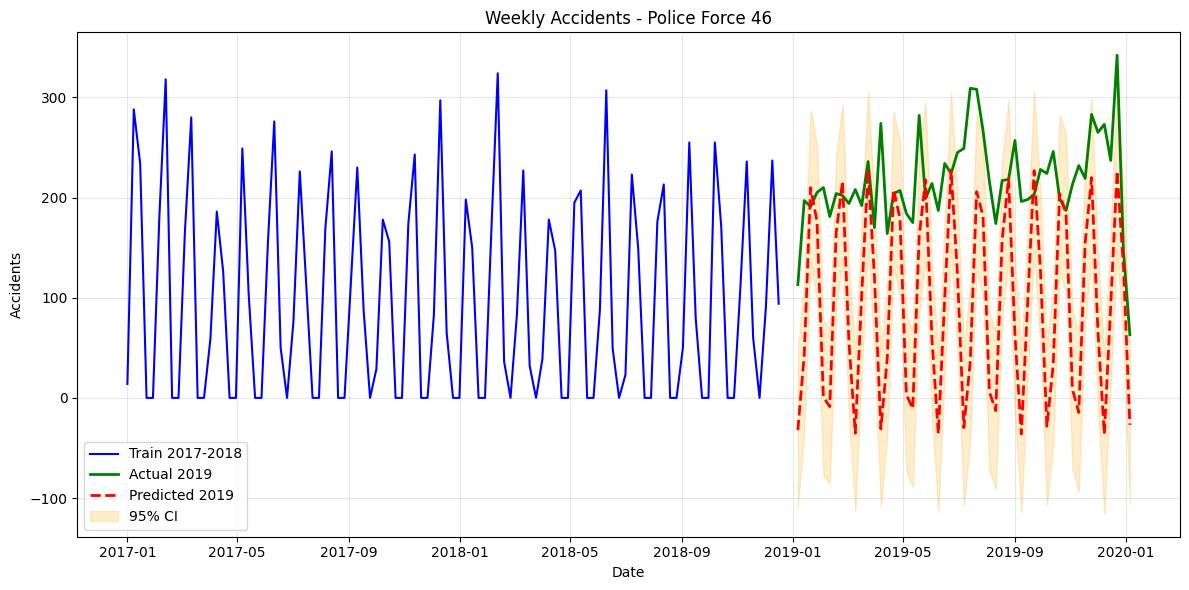

In [179]:
def plot_predictions(force):
    plt.figure(figsize=(12,6))
    plt.plot(train_data[force].index, train_data[force], label='Train 2017-2018', color='blue')
    plt.plot(test_data[force].index, test_data[force], label='Actual 2019', color='green', linewidth=2)
    plt.plot(test_data[force].index, predictions[force], label='Predicted 2019', color='red', linestyle='--', linewidth=2)
    ci = ci_dict[force]
    if ci is not None:
        plt.fill_between(test_data[force].index, ci.iloc[:,0], ci.iloc[:,1], color='orange', alpha=0.2, label='95% CI')
    plt.title(f'Weekly Accidents - Police Force {force}')
    plt.xlabel('Date')
    plt.ylabel('Accidents')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for force in selected_forces:
    plot_predictions(force)


In [180]:
# Prepare combined comparison dataframe
combined_comparison = []

for force in selected_forces:
    actual_total = test_data[force].sum()
    predicted_total = predictions[force].sum()
    diff = predicted_total - actual_total
    perc_diff = (diff / actual_total) * 100 if actual_total > 0 else 0
    combined_comparison.append({
        'Police Force': force,
        'Actual Total 2019': actual_total,
        'Predicted Total 2019': round(predicted_total,2),
        'Difference': round(diff,2),
        'Percentage Difference (%)': round(perc_diff,2),
        'Accuracy (%)': round(100 - abs(perc_diff),2)
    })

comparison_df = pd.DataFrame(combined_comparison)
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print("=== WEEKLY ACCIDENTS PREDICTION COMPARISON ===")
print(comparison_df)


=== WEEKLY ACCIDENTS PREDICTION COMPARISON ===
   Police Force  Actual Total 2019  Predicted Total 2019  Difference  \
0            46              11465               4935.57    -6529.43   
1             1              55059              22480.12   -32578.88   
2            20              14486               5720.69    -8765.31   

   Percentage Difference (%)  Accuracy (%)  
0                     -56.95         43.05  
1                     -59.17         40.83  
2                     -60.51         39.49  


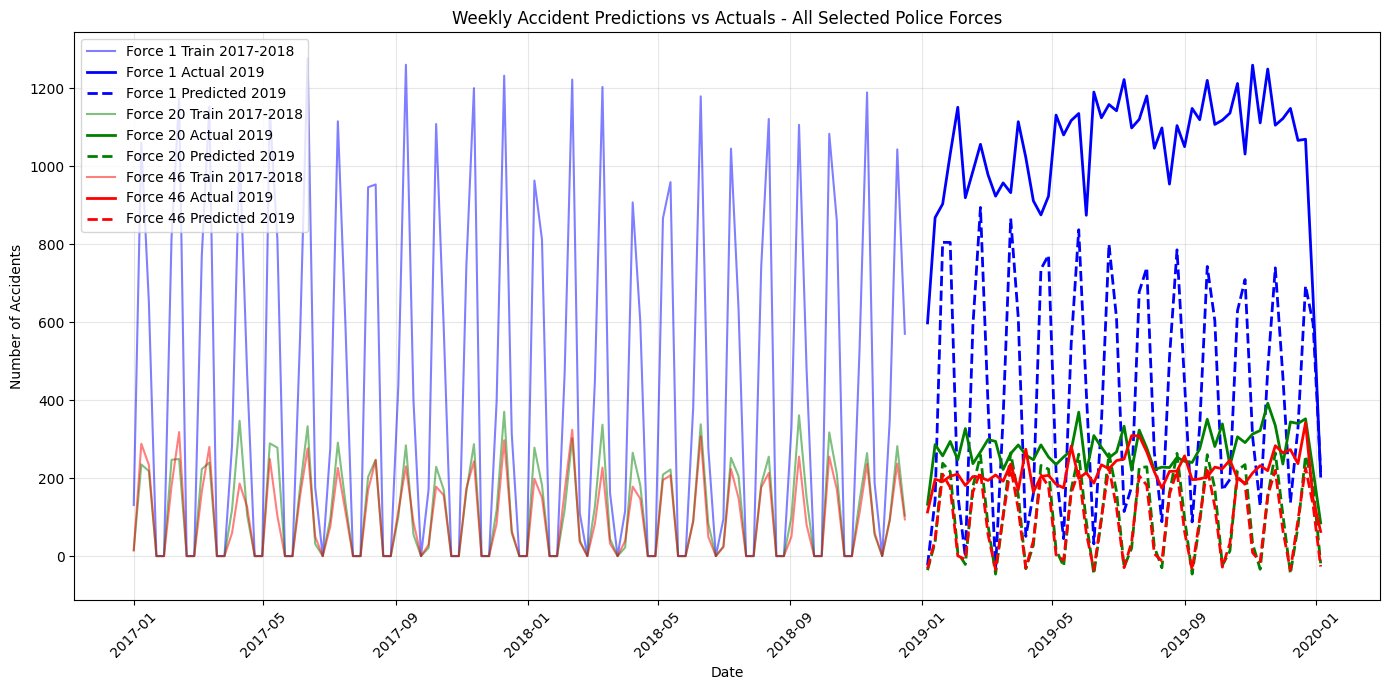

In [181]:
plt.figure(figsize=(14,7))

colors = ['blue', 'green', 'red']
for i, force in enumerate(selected_forces):
    # Training data
    plt.plot(train_data[force].index, train_data[force], label=f'Force {force} Train 2017-2018', color=colors[i], alpha=0.5)
    
    # Actual 2019
    plt.plot(test_data[force].index, test_data[force], label=f'Force {force} Actual 2019', color=colors[i], linewidth=2)
    
    # Predictions
    plt.plot(test_data[force].index, predictions[force], linestyle='--', color=colors[i], linewidth=2, label=f'Force {force} Predicted 2019')
    
plt.title('Weekly Accident Predictions vs Actuals - All Selected Police Forces')
plt.xlabel('Date')
plt.ylabel('Number of Accidents')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Question # 7

##### Identify the top thirty (30) Local Super Output Areas (LSOAs) for the City of Hull that recorded the highest number of road accidents in the first three months of 2019.

In [187]:
# merging lsoa to previous merged data to use as a base
# Merge LSOA data
merged_data = merged_data.merge(
    lsoa_2019[['lsoa01cd', 'lsoa01nm']], 
    left_on='lsoa_of_accident_location', 
    right_on='lsoa01cd', 
    how='left'
)


In [188]:
# Find LSOAs that belong to Hull by name
hull_mask = (
    lsoa_2019['lsoa01nm'].str.contains('Kingston upon Hull', case=False, na=False) |
    lsoa_2019['lsoa01nm'].str.contains(r'\bHull\b', case=False, na=False)
)

hull_lsoas = lsoa_2019.loc[hull_mask, ['lsoa01cd','lsoa01nm']].drop_duplicates()
print(f"Hull LSOAs detected: {len(hull_lsoas)}")
hull_lsoas.head()


Hull LSOAs detected: 163


,lsoa01cd,lsoa01nm
12755,E01012756,Kingston upon Hull 025A
12756,E01012757,Kingston upon Hull 025B
12757,E01012758,Kingston upon Hull 018A
12758,E01012759,Kingston upon Hull 025C
12759,E01012760,Kingston upon Hull 025D


In [189]:
hull_2019 = merged_data[merged_data['lsoa_of_accident_location'].isin(hull_lsoas['lsoa01cd'])].copy()
print(f"Total Hull accidents in 2019: {len(hull_2019)}")


Total Hull accidents in 2019: 1660


In [190]:
jan_mar = hull_2019[
    (hull_2019['date'] >= '2019-01-01') & (hull_2019['date'] < '2019-04-01')
].copy()

top30_counts = (jan_mar
    .groupby('lsoa_of_accident_location')
    .size()
    .sort_values(ascending=False)
    .head(30)
    .rename('count')
    .reset_index()
)

top30_codes = top30_counts['lsoa_of_accident_location'].tolist()

# attach readable names
top30_named = top30_counts.merge(hull_lsoas, left_on='lsoa_of_accident_location', right_on='lsoa01cd', how='left')
print("Top 30 Hull LSOAs (Jan–Mar 2019) by accidents:")
top30_named.head(10)


Top 30 Hull LSOAs (Jan–Mar 2019) by accidents:


,lsoa_of_accident_location,count,lsoa01cd,lsoa01nm
0,E01012869,26,E01012869,Kingston upon Hull 015C
1,E01012851,18,E01012851,Kingston upon Hull 029A
2,E01012809,18,E01012809,Kingston upon Hull 026C
3,E01012848,16,E01012848,Kingston upon Hull 020B
4,E01012914,14,E01012914,Kingston upon Hull 012C
5,E01012889,12,E01012889,Kingston upon Hull 030B
6,E01012882,12,E01012882,Kingston upon Hull 032A
7,E01012883,10,E01012883,Kingston upon Hull 032B
8,E01012854,10,E01012854,Kingston upon Hull 029C
9,E01012855,10,E01012855,Kingston upon Hull 029D


In [191]:
jan_jun_top30 = hull_2019[
    (hull_2019['date'] >= '2019-01-01') & (hull_2019['date'] < '2019-07-01') &
    (hull_2019['lsoa_of_accident_location'].isin(top30_codes))
].copy()

daily_train = (
    jan_jun_top30
    .set_index('date')
    .resample('D')
    .size()
    .rename('accident_count')
)

# ensure continuous daily index with zeros for missing days
full_index = pd.date_range('2019-01-01', '2019-06-30', freq='D')
daily_train = daily_train.reindex(full_index, fill_value=0)
print(daily_train.head(), daily_train.tail(), sep='\n\n')


2019-01-01    2
2019-01-02    4
2019-01-03    2
2019-01-04    2
2019-01-05    0
Freq: D, Name: accident_count, dtype: int64

2019-06-26    2
2019-06-27    4
2019-06-28    0
2019-06-29    2
2019-06-30    4
Freq: D, Name: accident_count, dtype: int64


In [192]:
best_model = None
best_aic = np.inf
best_order = None
best_seasonal = None

# modest grid search
orders = [(1,0,1),(1,1,1),(2,1,1)]
seasonals = [(1,0,1,7),(0,1,1,7),(1,1,1,7)]

for order in orders:
    for seasonal in seasonals:
        try:
            m = SARIMAX(daily_train, order=order, seasonal_order=seasonal,
                        enforce_stationarity=False, enforce_invertibility=False)
            res = m.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_model = res
                best_order = order
                best_seasonal = seasonal
        except Exception as e:
            # skip combos that fail to converge
            pass

print(f"Best SARIMA order={best_order}, seasonal={best_seasonal}, AIC={best_aic:.2f}")


Best SARIMA order=(1, 1, 1), seasonal=(0, 1, 1, 7), AIC=879.84


In [193]:
# Forecast horizon: 2019-07-01 to 2019-07-31
forecast_horizon = 31
pred = best_model.get_forecast(steps=forecast_horizon)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()

# Build a tidy forecast frame with dates
forecast_index = pd.date_range('2019-07-01', '2019-07-31', freq='D')
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'predicted_accidents': np.clip(pred_mean.values, 0, None)  # no negative counts
}).set_index('date')

# optional rounding to integers (comment out if you prefer floats)
forecast_df['predicted_accidents'] = forecast_df['predicted_accidents'].round().astype(int)

print("Forecast for July 2019 (Top 30 Hull LSOAs combined):")
forecast_df.head(10)


Forecast for July 2019 (Top 30 Hull LSOAs combined):


,predicted_accidents
date,
2019-07-01,3
2019-07-02,3
2019-07-03,3
2019-07-04,1
2019-07-05,3
2019-07-06,1
2019-07-07,2
2019-07-08,3
2019-07-09,3


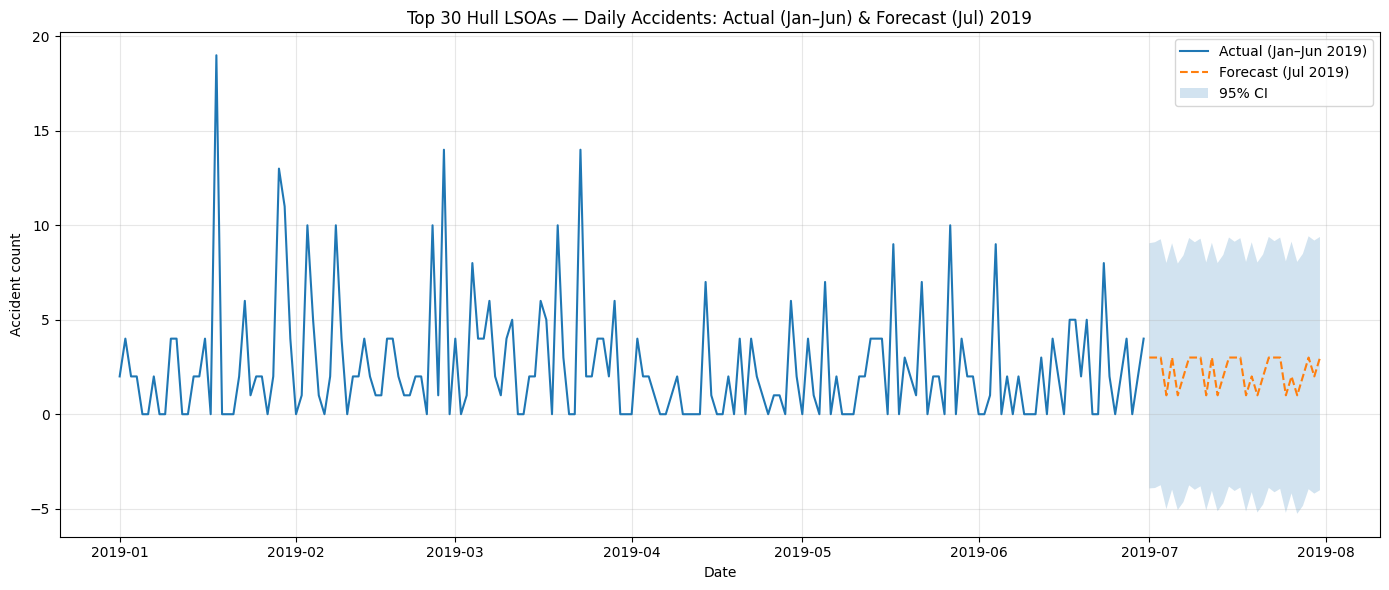

In [194]:
plt.figure(figsize=(14,6))

# Actuals (Jan–Jun)
plt.plot(daily_train.index, daily_train.values, label='Actual (Jan–Jun 2019)')

# Forecast (Jul)
plt.plot(forecast_df.index, forecast_df['predicted_accidents'], linestyle='--', label='Forecast (Jul 2019)')

# CI (use model’s CI; align to July index)
ci_jul = pred_ci.copy()
ci_jul.index = forecast_index
plt.fill_between(ci_jul.index, ci_jul.iloc[:,0], ci_jul.iloc[:,1], alpha=0.2, label='95% CI')

plt.title('Top 30 Hull LSOAs — Daily Accidents: Actual (Jan–Jun) & Forecast (Jul) 2019')
plt.xlabel('Date'); plt.ylabel('Accident count')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()


In [195]:
# Total predicted accidents for July
total_july_pred = forecast_df['predicted_accidents'].sum()
avg_daily_pred = forecast_df['predicted_accidents'].mean()
print(f"Total forecast (Jul 2019): {total_july_pred} accidents across top 30 LSOAs")
print(f"Average per day (Jul 2019): {avg_daily_pred:.2f}")

# If you want to sanity-check weekly seasonality in Jan–Jun:
weekly_profile = daily_train.groupby(daily_train.index.dayofweek).mean()
weekly_profile.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
print("\nAverage accidents by weekday (Jan–Jun, Top 30 LSOAs):")
print(weekly_profile)


Total forecast (Jul 2019): 70 accidents across top 30 LSOAs
Average per day (Jul 2019): 2.26

Average accidents by weekday (Jan–Jun, Top 30 LSOAs):
Mon    3.120000
Tue    2.846154
Wed    3.076923
Thu    1.807692
Fri    2.846154
Sat    1.769231
Sun    2.192308
Name: accident_count, dtype: float64


In [196]:
# show the first/last rows and a quick summary
print(daily_train.head())
print(daily_train.tail())
print("\nForecast (first 10 days):")
print(forecast_df.head(10))


2019-01-01    2
2019-01-02    4
2019-01-03    2
2019-01-04    2
2019-01-05    0
Freq: D, Name: accident_count, dtype: int64
2019-06-26    2
2019-06-27    4
2019-06-28    0
2019-06-29    2
2019-06-30    4
Freq: D, Name: accident_count, dtype: int64

Forecast (first 10 days):
            predicted_accidents
date                           
2019-07-01                    3
2019-07-02                    3
2019-07-03                    3
2019-07-04                    1
2019-07-05                    3
2019-07-06                    1
2019-07-07                    2
2019-07-08                    3
2019-07-09                    3
2019-07-10                    3


Residuals summary:
count    181.000000
mean      -0.249879
std        3.493366
min       -9.641076
25%       -2.263240
50%       -1.023834
75%        1.224299
max       15.612984
dtype: float64


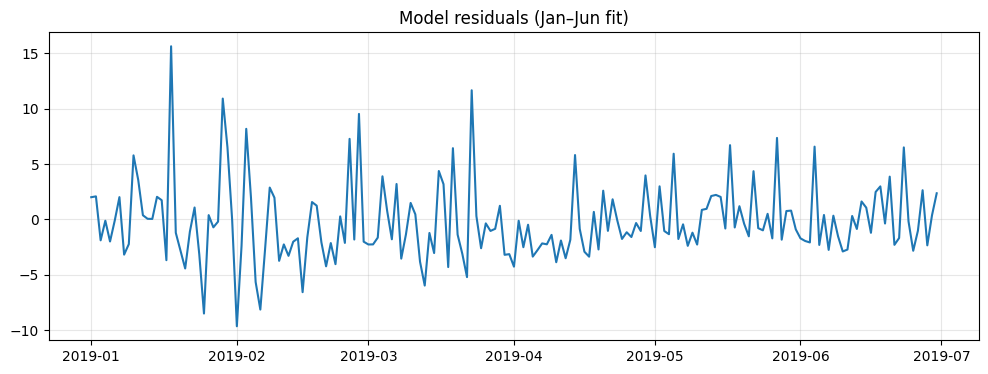

<Figure size 600x400 with 0 Axes>

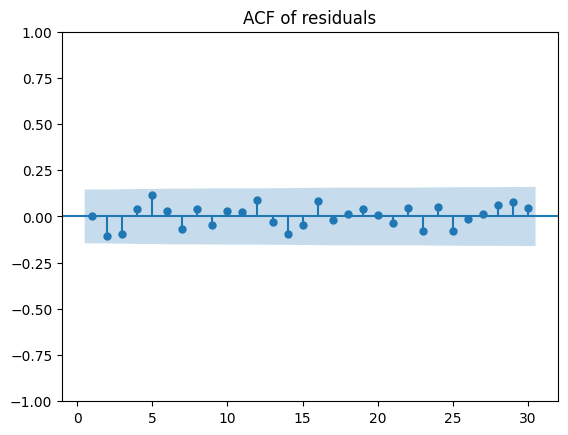

In [197]:
resid = best_model.resid
print("Residuals summary:")
print(resid.describe())

# plot residuals and ACF
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,4))
plt.plot(resid)
plt.title('Model residuals (Jan–Jun fit)')
plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(6,4))
plot_acf(resid.dropna(), lags=30, zero=False)
plt.title('ACF of residuals')
plt.show()


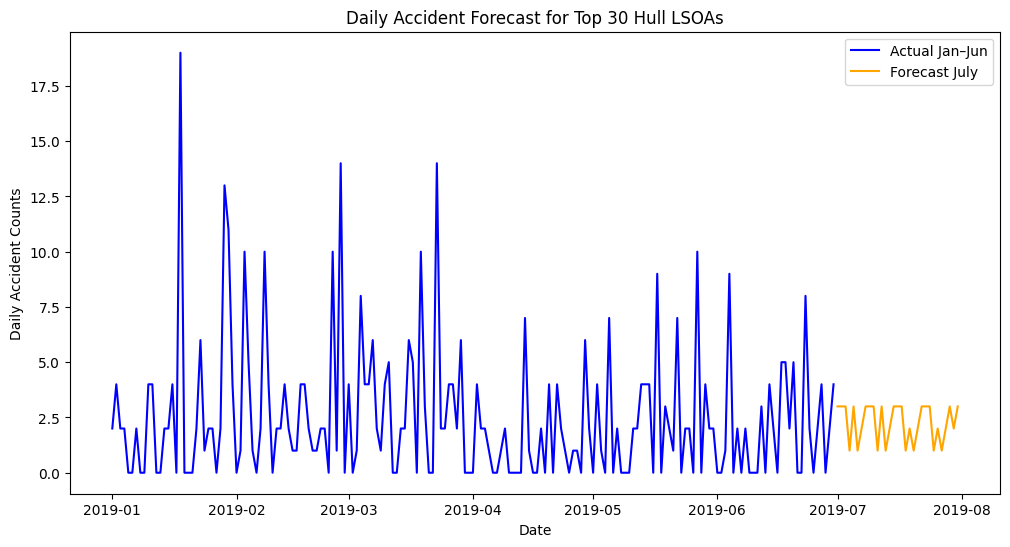

In [200]:
plt.figure(figsize=(12,6))

# Plot actual training data
plt.plot(daily_train.index, daily_train.values, label='Actual Jan–Jun', color='blue')

# Forecast July (first column of forecast_df)
plt.plot(forecast_df.index, forecast_df.iloc[:, 0], label='Forecast July', color='orange')

# If forecast_df has confidence intervals (2nd & 3rd columns)
if forecast_df.shape[1] >= 3:
    plt.fill_between(forecast_df.index,
                     forecast_df.iloc[:, 1],   # lower bound
                     forecast_df.iloc[:, 2],   # upper bound
                     color='orange', alpha=0.2, label='95% CI')

plt.xlabel('Date')
plt.ylabel('Daily Accident Counts')
plt.title('Daily Accident Forecast for Top 30 Hull LSOAs')
plt.legend()
plt.show()
